# Upgrade tensorflow

In [1]:
!pip install --upgrade tensorflow

  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/f9/37/b97abb360b551fbf5870a0ee07e39ff9c655e6e3e2f839bc88be81361842/tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/8f/aa/ba0014cc4659328dc818a28827be78e6d97312ab0cb98105a770924dc11e/absl_py-2.3.1-py3-none-any.whl.metadata
  Obtaining dependency information for astunparse>=1.6.0 from https://files.pythonhosted.org/packages/2b/03/13dde6512ad7b4557eb792fbcf0c653af6076b81e5941d36ec61f7ce6028/astunparse-1.6.3-py2.py3-none-any.whl.metadata
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Obtaining dependency information for flatbuffers>=24.3.25 from https://files.pythonhosted.org/packages/b8/25/155f9f080d5e4bc0082edfda032ea2bc2b8fab3f4d25d46c1e9dd22a1a89/flatbuffers-25.2.10-py2.py3-none-any.whl.metadata
  Obtaining dependency information for gast!=0.5.0,!=0.5.1,!=0.5.2,>=0


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
! pip install pandas

  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/28/30/8114832daff7489f179971dbc1d854109b7f4365a546e3ea75b6516cea95/pandas-2.3.2-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for pytz>=2020.1 from https://files.pythonhosted.org/packages/81/c4/34e93fe5f5429d7570ec1fa436f1986fb1f00c3e0f43a589fe2bbcd22c3f/pytz-2025.2-py2.py3-none-any.whl.metadata
  Obtaining dependency information for tzdata>=2022.7 from https://files.pythonhosted.org/packages/5c/23/c7abc0ca0a1526a0774eca151daeb8de62ec457e77262b66b359c3c7679e/tzdata-2025.2-py2.py3-none-any.whl.metadata
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB 960.0 kB/s eta 0:00:12
    --------------------------------------- 0.2/11.0 MB 2.1 MB/s eta 0:00:06
    --------------------------------------- 0.2/11.0 MB 2.1 MB/s eta 0:00:06
   - -------------------------------------- 0.3/11.0 MB 1.7 MB/s eta 0:00:0


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Pengujian komputasi

In [ ]:
import numpy as np # library untuk komputasi numerik dan manipulasi array
import pandas as pd # library untuk membuat dataframe
import tensorflow as tf # library utama untuk deep learning (iniisiasi model dan evaluasi model )
import os # library untuk operasi sistem
from glob import glob # library untuk pencarian file
import PIL # library untuk memproses gambar (dalam bentuk objek gambar)
from collections import defaultdict # library untuk membuat dictionary
import matplotlib.pyplot as plt # library untuk visualisasi data

## inisialisasi dataset dan membuat file path 


In [2]:
DIR = r"Data Pengujian Komputasi_Resize\20 Data"

# Path X-ray dan Mask
xray_dir = os.path.join(DIR, "X-Ray")
mask_dir = os.path.join(DIR, "Mask")

# Ambil semua gambar X-ray dan mask
lung_image_paths = glob(os.path.join(xray_dir, "*.png")) 
mask_image_paths = glob(os.path.join(mask_dir, "*.PNG"))

# Cek jumlah
print(f"Terdapat {len(lung_image_paths)} X-ray  and {len(mask_image_paths)} masks.")

Terdapat 20 X-ray  and 20 masks.


In [3]:
related_paths = defaultdict(list)

# Cek kesesuaian antara file X-ray dan Mask berdasarkan nama file
for img_path in lung_image_paths:
    # Ambil nama file dari path X-ray (tanpa .png)
    img_name = os.path.basename(img_path).replace('.png', '')  # Misal: "Data (72)"

    # Ekstrak nomor di dalam tanda kurung dari nama file X-ray
    img_number = img_name.split('(')[-1].split(')')[0].strip()  # Mengambil '72'

    for mask_path in mask_image_paths:
        # Ambil nama file dari path Mask (tanpa .PNG)
        mask_name = os.path.basename(mask_path).replace('.PNG', '')  # Misal: "mask_Data (379)"

        # Ekstrak nomor di dalam tanda kurung dari nama file Mask
        mask_number = mask_name.split('(')[-1].split(')')[0].strip()  # Mengambil '379'

        # Cek apakah nomor di dalam tanda kurung cocok
        if img_number == mask_number:
            # Jika cocok, simpan path gambar dan mask
            related_paths["image_path"].append(img_path)
            related_paths["mask_path"].append(mask_path)

# Konversi hasil pencocokan ke dalam DataFrame
paths_df = pd.DataFrame.from_dict(related_paths)

# Cek apakah DataFrame berisi data
print(paths_df.head())

                                          image_path  \
0  Data Pengujian Komputasi_Resize\20 Data\X-Ray\...   
1  Data Pengujian Komputasi_Resize\20 Data\X-Ray\...   
2  Data Pengujian Komputasi_Resize\20 Data\X-Ray\...   
3  Data Pengujian Komputasi_Resize\20 Data\X-Ray\...   
4  Data Pengujian Komputasi_Resize\20 Data\X-Ray\...   

                                           mask_path  
0  Data Pengujian Komputasi_Resize\20 Data\Mask\m...  
1  Data Pengujian Komputasi_Resize\20 Data\Mask\m...  
2  Data Pengujian Komputasi_Resize\20 Data\Mask\m...  
3  Data Pengujian Komputasi_Resize\20 Data\Mask\m...  
4  Data Pengujian Komputasi_Resize\20 Data\Mask\m...  


In [4]:
paths_df.to_csv('path df_20 DATA.csv', index=False)
print("paths_df berhasil disimpan ke file")

paths_df berhasil disimpan ke file


### <b> Visualisassi pasangan </b>

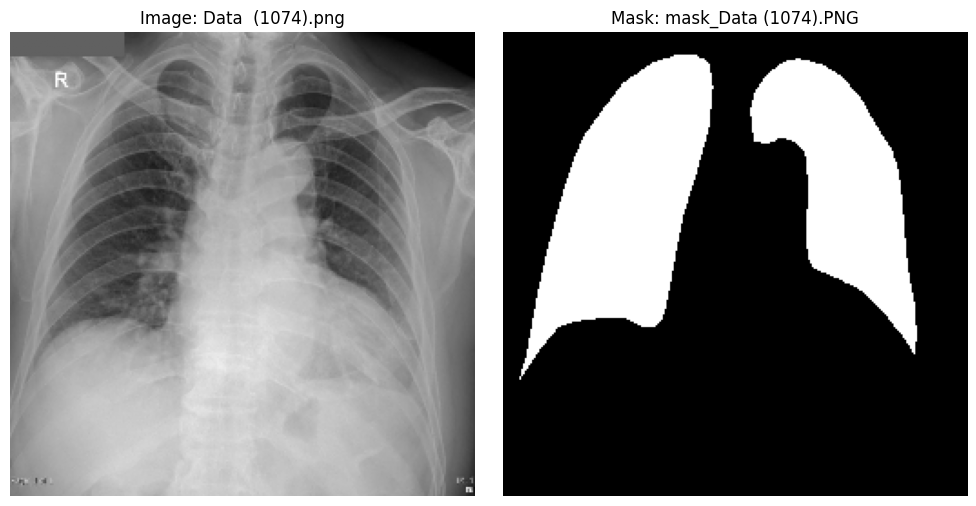

In [ ]:
def display_image_mask(df, index): # Fungsi untuk menampilkan pasangan gambar X-ray dan Mask 
  if index < 0 or index >= len(df):
    print(f"Index {index} out of bounds.")
    return

  img_path = df.loc[index, 'image_path'] # Ambil path gambar X-ray dari DataFrame
  mask_path = df.loc[index, 'mask_path'] # Ambil path gambar Mask dari DataFrame

  try:
    img = PIL.Image.open(img_path) # Membuka gambar X-ray menggunkan pillow
    mask = PIL.Image.open(mask_path) # Membuka gambar Mask menggunakan pillow

    fig, axes = plt.subplots(1, 2, figsize=(10, 5)) # Membuat subplot untuk menampilkan gambar X-ray dan Mask
    axes[0].imshow(img, cmap='gray') # tampilkan gambar X-ray
    axes[0].set_title(f"Image: {os.path.basename(img_path)}") # Judul gambar X-ray
    axes[0].axis('off') # Hilangkan sumbu

    axes[1].imshow(mask, cmap='gray') # tampilkan gambar Mask
    axes[1].set_title(f"Mask: {os.path.basename(mask_path)}")
    axes[1].axis('off')

    plt.tight_layout() # Atur layout secara otomatis
    plt.show() #show 

  except FileNotFoundError: # Jika file tidak ditemukan
    print(f"File tdk ditemukan pada indeks ke- {index}. Image path: {img_path}, Mask path: {mask_path}")  # tampilkan pesan file tdk ditemukan
  except Exception as e: # Jika ada error lain
    print(f" error: {e}") # tampilkan pesan error
display_image_mask(paths_df, 0) #eksekusi fungsi untuk menampilkan gambar X-ray dan Mask pada indeks ke-0

In [ ]:
nama_dir = r"Data Pengujian Komputasi_Resize\1 Data\X-Ray" 
namafile_paths = sorted(glob(os.path.join(xray_dir, "*.png"))) # Ambil semua file .png di direktori dan urutkan
# Simpan hanya nama file (tanpa path)
filenames = [os.path.basename(f) for f in namafile_paths] 
print(filenames[:5])   # Tampilkan 5 nama file pertama

['Data  (1074).png', 'Data  (1075).png', 'Data  (1077).png', 'Data  (1078).png', 'Data  (1079).png']


# Mengkonversi ke array 4 dimensi dan tipe data float32

In [7]:
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm

def prepare_train_test(df=pd.DataFrame(), color_mode="gray"):
    img_array = []
    mask_array = []

    # Proses gambar
    for image_path in tqdm(df.image_path, desc="Loading images"):
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        image = image / 255.0
        img_array.append(image)

    # Proses mask
    for mask_path in tqdm(df.mask_path, desc="Loading masks"):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = mask / 255.0
        mask_array.append(mask)

    # Konversi ke NumPy array
    img_array = np.array(img_array)
    mask_array = np.array(mask_array)
    return img_array, mask_array

img_array, mask_array = prepare_train_test(df=paths_df, color_mode="gray")

print(f"Image array shape: {img_array.shape}")
print(f"Mask array shape: {mask_array.shape}")

Loading images:   0%|          | 0/20 [00:00<?, ?it/s]

Loading masks: 100%|██████████| 20/20 [00:00<00:00, 906.99it/s]

Image array shape: (20, 256, 256)
Mask array shape: (20, 256, 256)


In [ ]:
# mengubah dimensi array menjadi 4 dimensi  (jumlah_gambar, 256, 256, 1) 
img_side_size = 256
img_array = np.array(img_array).reshape(len(img_array), img_side_size, img_side_size, 1) 
mask_array = np.array(mask_array).reshape(len(mask_array), img_side_size, img_side_size, 1)
print(f"ukuran dimensi  X Ray: {img_array.shape}")
print(f"ukuran dimensi Mask : {mask_array.shape}")

ukuran dimensi  X Ray: (20, 256, 256, 1)
ukuran dimensi Mask : (20, 256, 256, 1)


In [9]:
print ("BENTUK SEBELUM DIKONVERSI")
print(f"Image array dtype: {img_array.dtype}")
print(f"Mask array dtype: {mask_array.dtype}")

BENTUK SEBELUM DIKONVERSI
Image array dtype: float64
Mask array dtype: float64


In [10]:
# Mengkonversi  tipe data float32
img_array = img_array.astype('float32')
mask_array = mask_array.astype('float32')

In [11]:
print ("BENTUK SETELAH  DIKONVERSI")
print(f"Image array dtype: {img_array.dtype}")
print(f"Mask array dtype: {mask_array.dtype}")

BENTUK SETELAH  DIKONVERSI
Image array dtype: float32
Mask array dtype: float32


# INISIASI MODEL DAN DEPLOY MODEL

In [ ]:
from tensorflow.keras.models import load_model # libary untuk memuat model yang telah disimpan

model = load_model(r'Model AI\U-Net.h5') # ini adalah model U-Net
model2 = load_model(r'Model AI\L-UNet.h5') #ini adalah model L-UNet
print("Model berhasil dimuat.") # untuk memastikan model telah dimuat dengan benar

Model berhasil dimuat.


In [ ]:
from tensorflow.keras.models import load_model # pustaka untuk memuat model 

model = load_model(r'Model AI\U-Net.h5') # inisialisasi model U-Net
model2 = load_model(r'Model AI\L-UNet.h5') # inisialisasi model L-UNet
print("Model berhasil dimuat.") # untuk memastikan model telah dimuat dengan benar

# penggalan kode

In [ ]:
import psutil # library untuk memantau penggunaan sumber daya sistem (CPU, memori, dll)

def get_memory_usage(): # fungsi untuk mendapatkan penggunaan memori dalam MB
    process = psutil.Process(os.getpid()) # mendapatkan proses saat ini (kode PID)
    return process.memory_info().rss / 1024 ** 2  #  dapatkan penggunaan memori pada saat ini dan dikonversi ke MB ,
# rss = resident set size, yaitu jumlah memori fisik yang digunakan oleh proses saati ini (Python) dalam byte

In [ ]:
import time # untuk mengukur waktu eksekusi
import psutil # untuk mengukur penggunaan memori

# Mengukur penggunaan memori dan waktu eksekusi
start_time = time.perf_counter() #ambil waktu awal
memori_awal = get_memory_usage()  #ambil memori awal


def get_memory_usage(): # FUNGSI UNTUK MENGHITUNG PENGGUNAAN MEMORI
    process = psutil.Process(os.getpid()) # mendapatkan proses saat ini
    return process.memory_info().rss / 1024 ** 2  # SIMPAN DALAM MB

"""
Baris kode prograam   UTAMA
untuk melakukan prediksi menggunakan model U-Net atau L-UNet
"""

#menghitung total memori yang digunakan dan waktu inferensi
stop_time = time.perf_counter() #ambil waktu akhir
memori_akhir = get_memory_usage()   #ambil memori akhir
waktuinferensi = stop_time - start_time # menghitung waktu eksekusi
totalmemori = memori_akhir - memori_awal # menghitung penggunaan memori
# konversi ke dalam format yang lebih mudah dibaca
print(f"Penggunaan memori: {totalmemori:.2f} MB") #menampilkan penggunaan memori
print(f"Waktu inferensi: {waktuinferensi:.2f} detik") #menampilkan waktu inferensi

Penggunaan memori: 0.00 MB
Waktu inferensi: 0.00 detik


# <b> Model U-Net </b>

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Rata-rata IoU: 0.9106
Rata-rata Akurasi: 0.9746


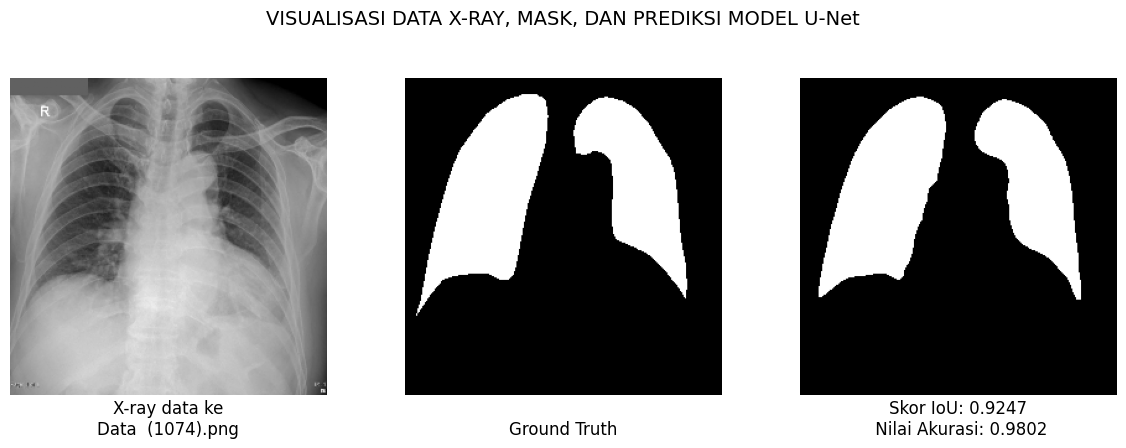

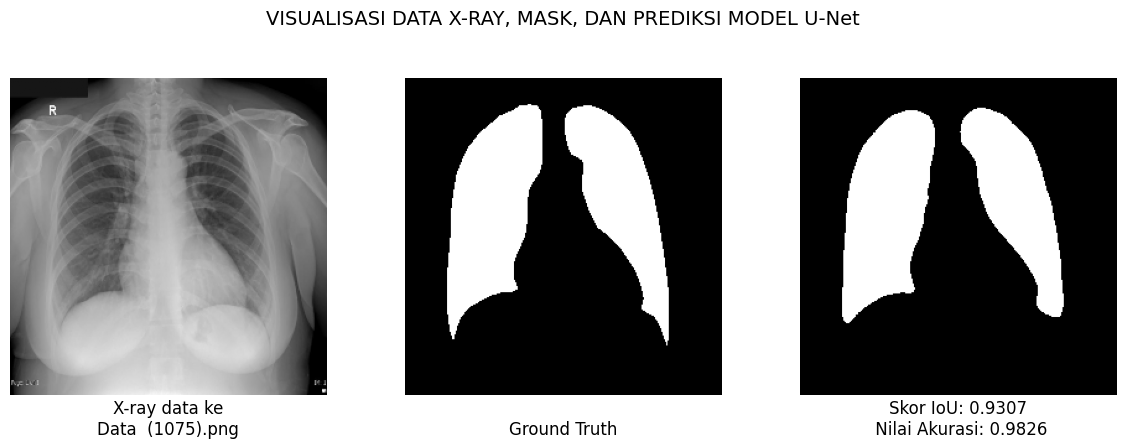

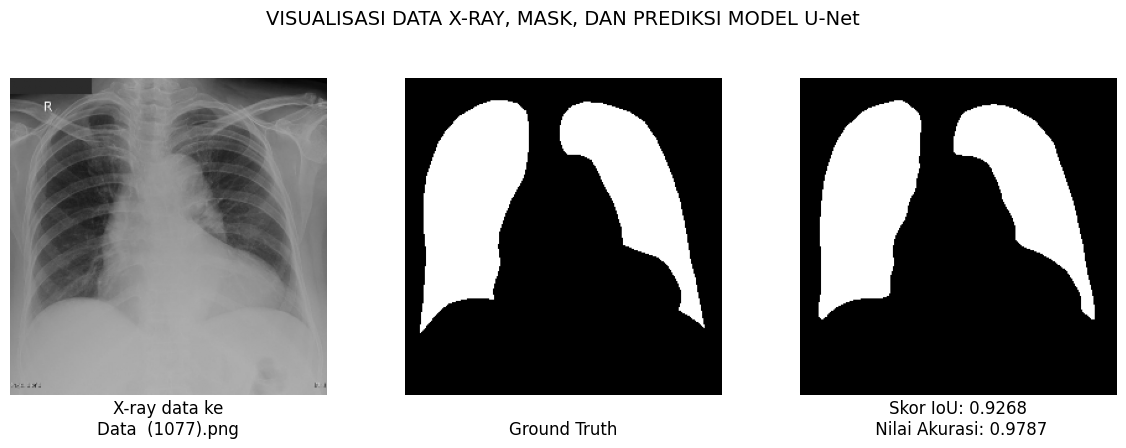

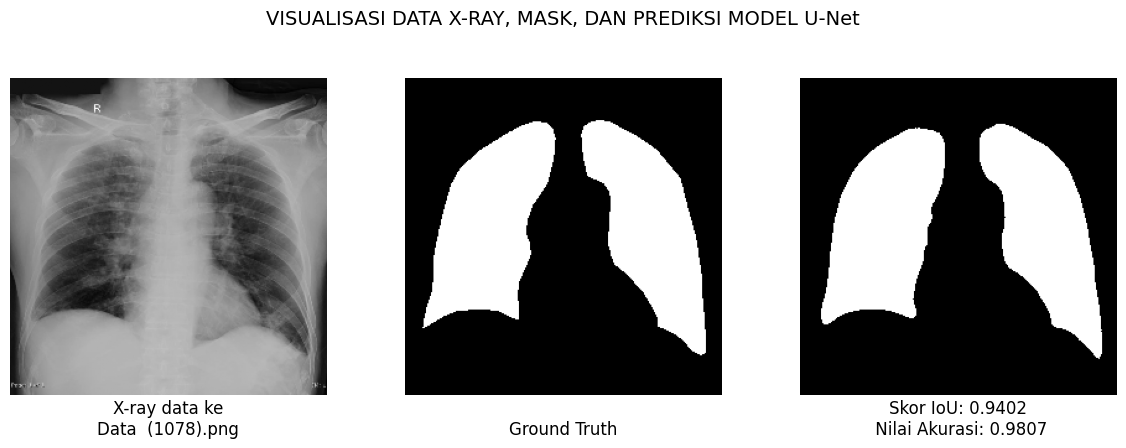

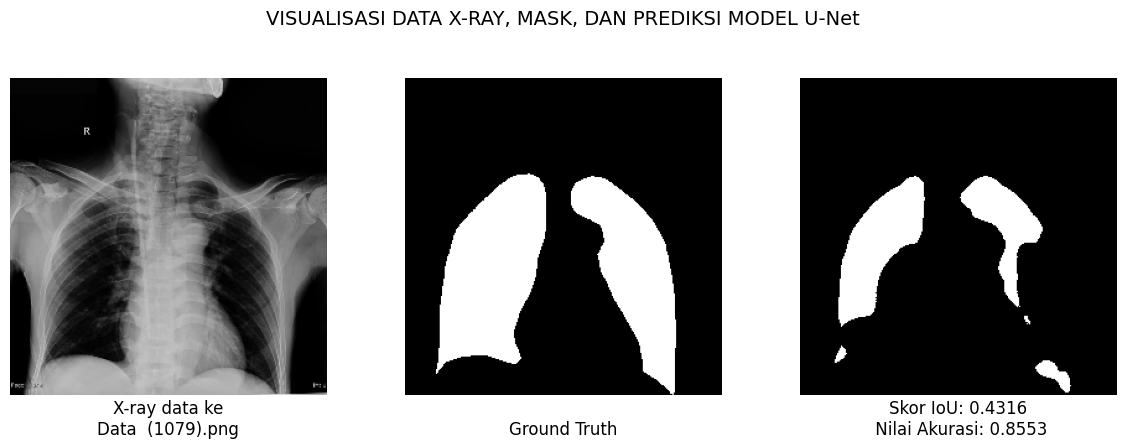

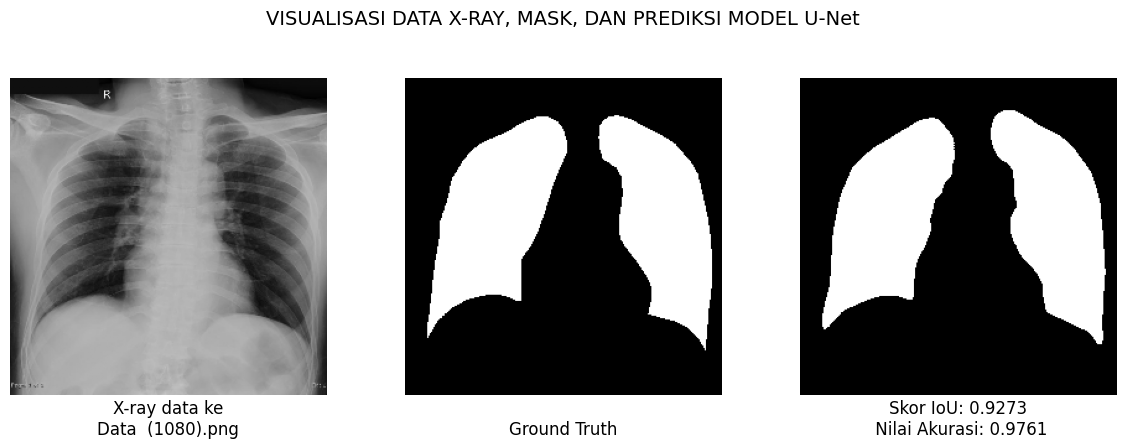

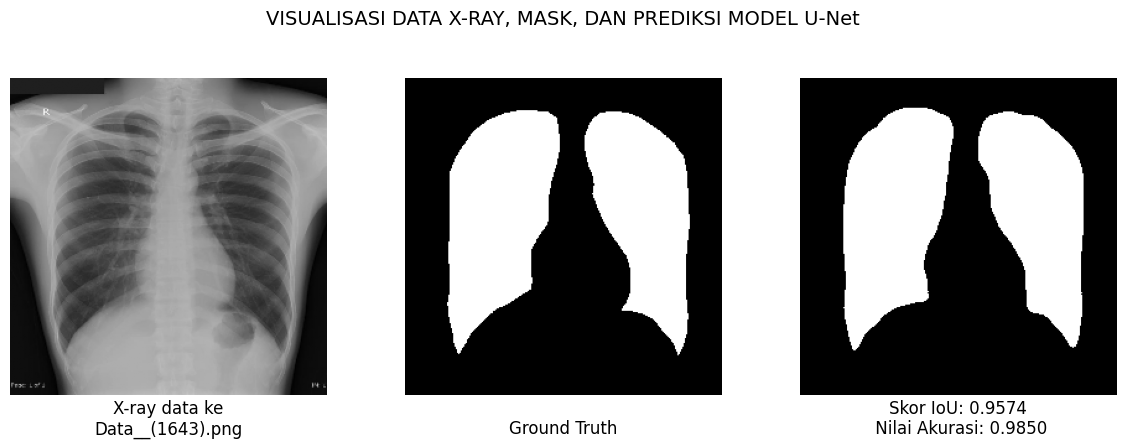

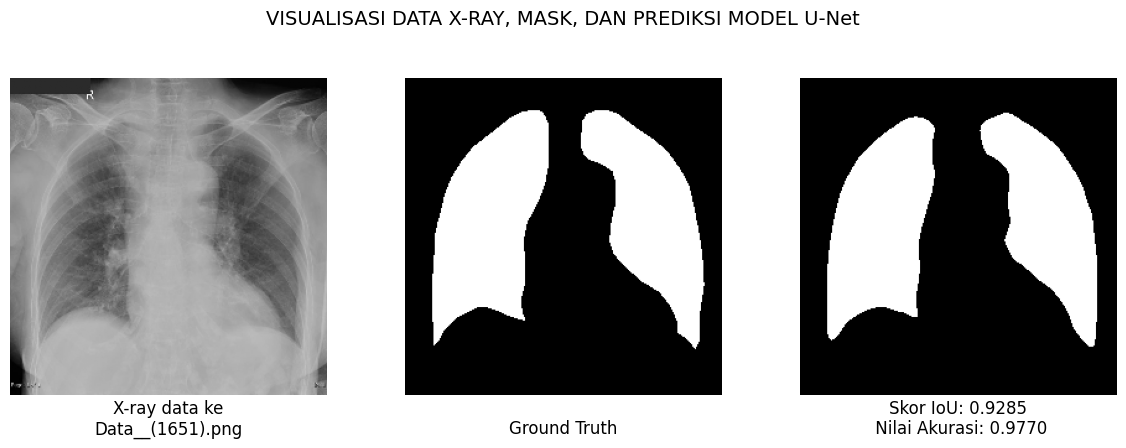

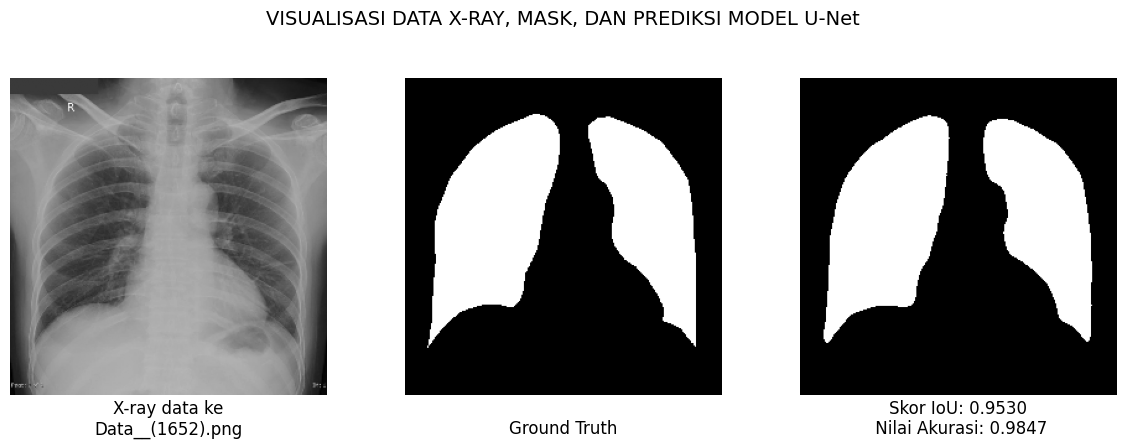

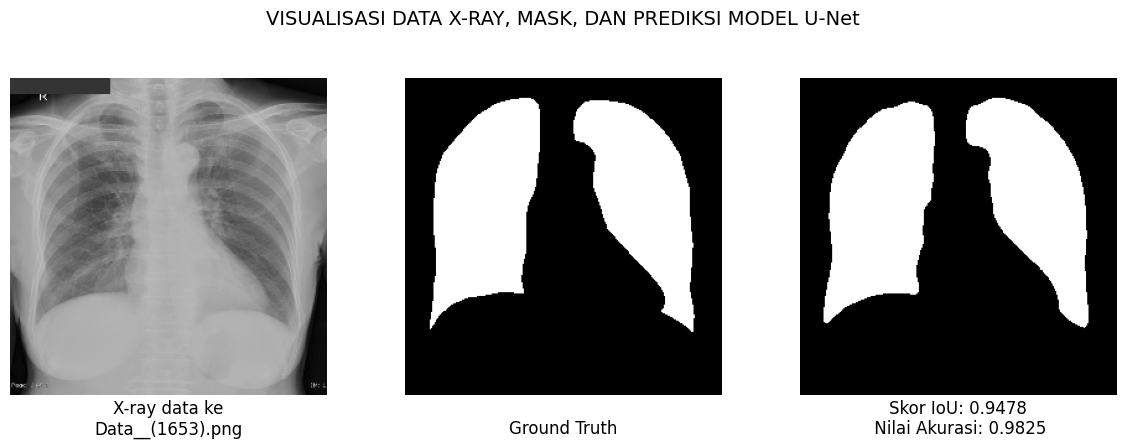

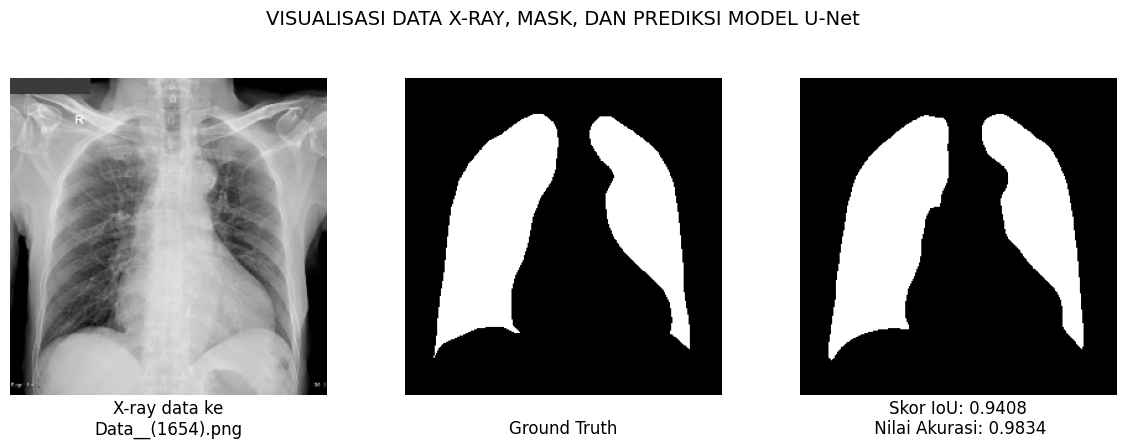

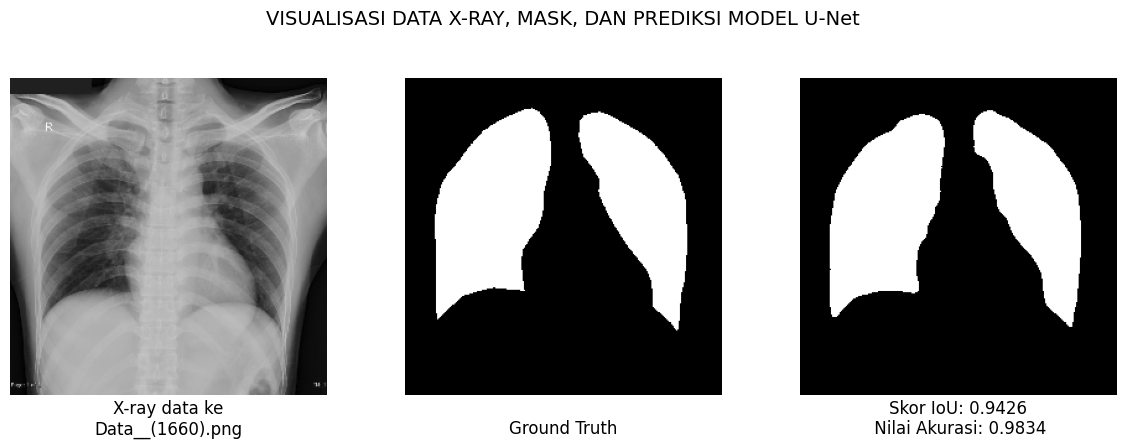

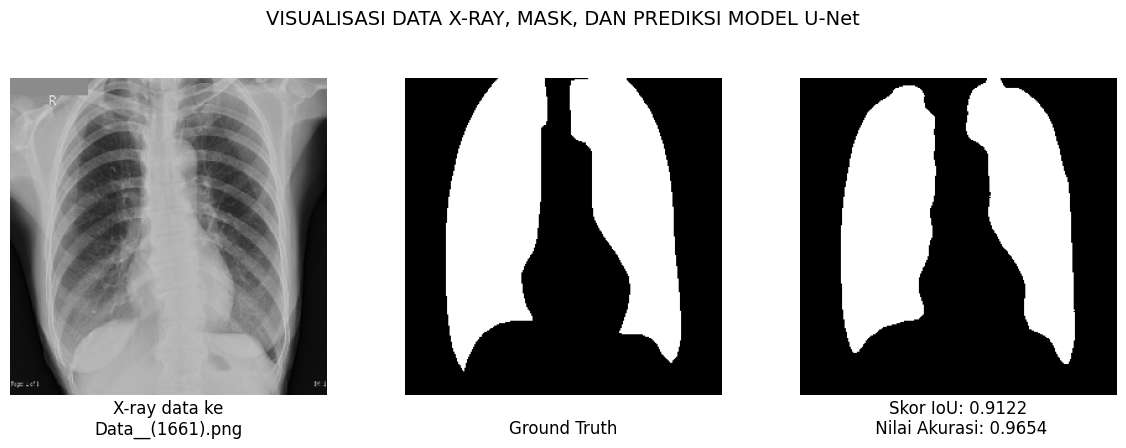

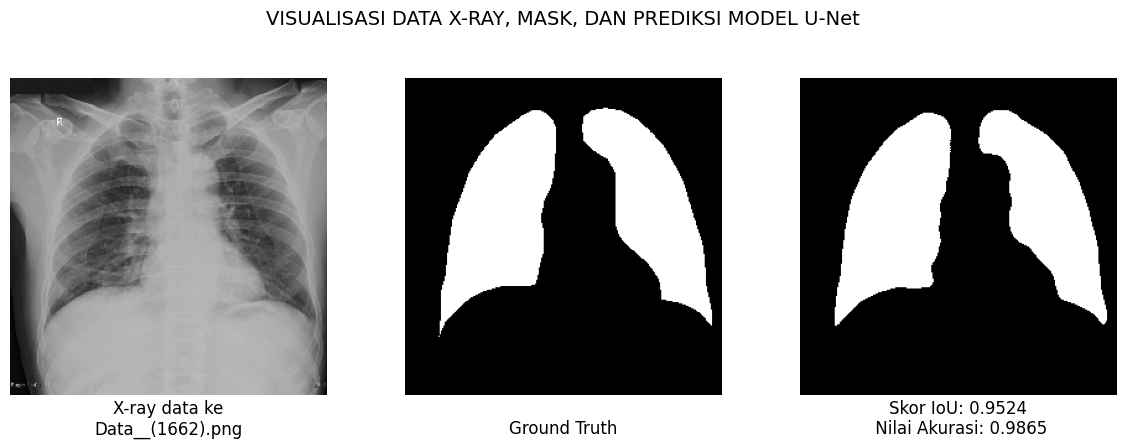

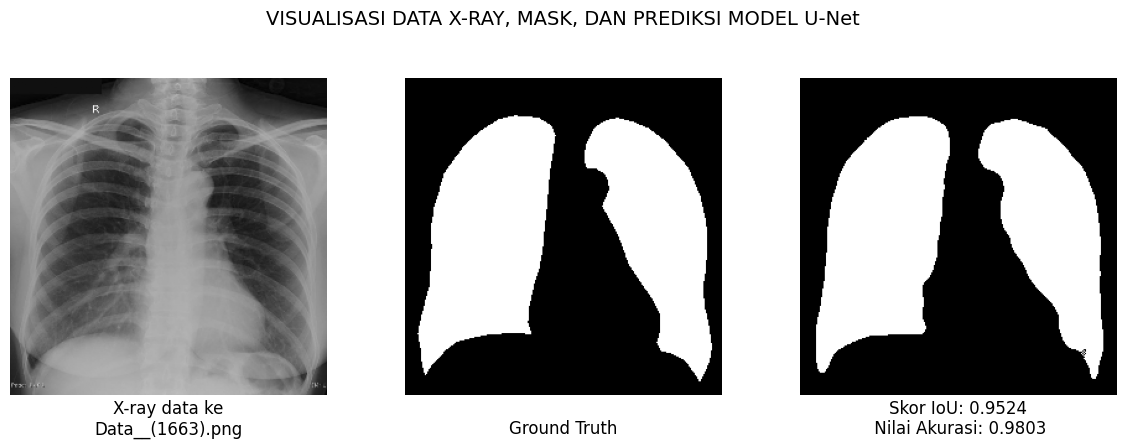

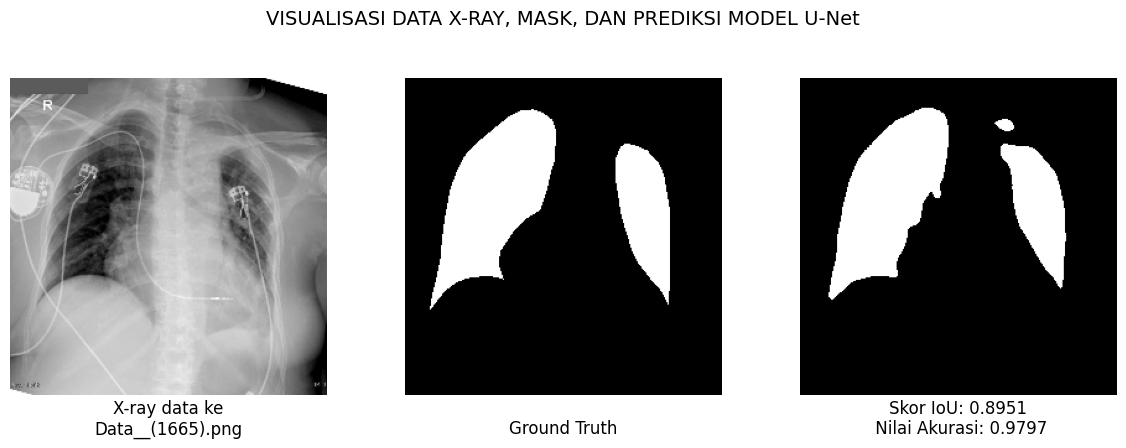

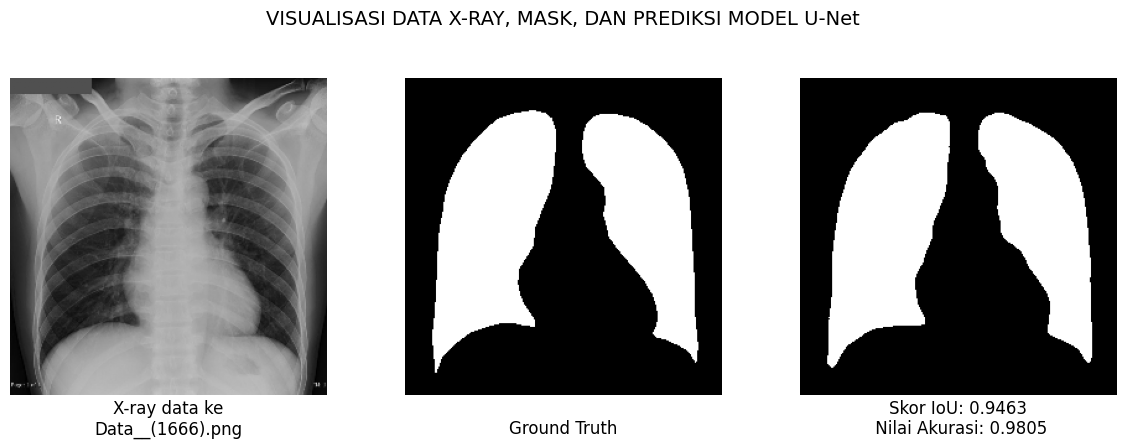

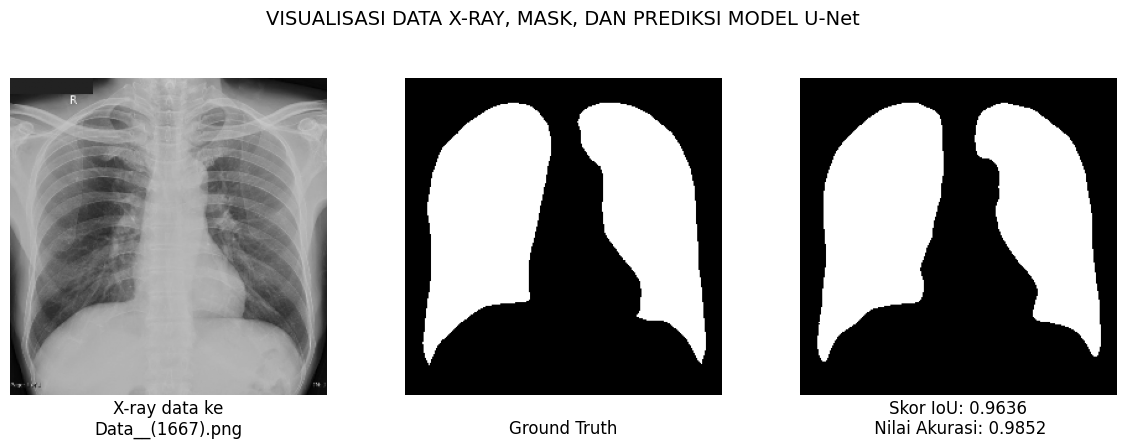

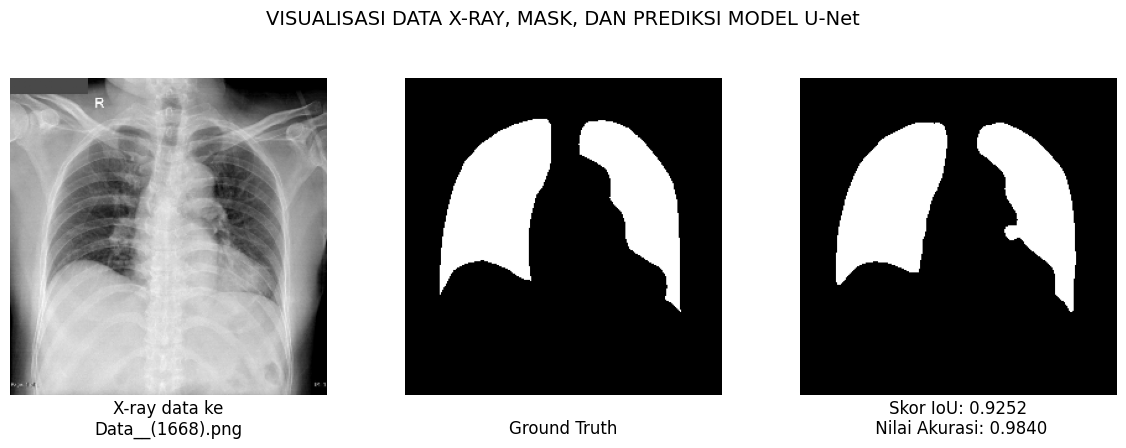

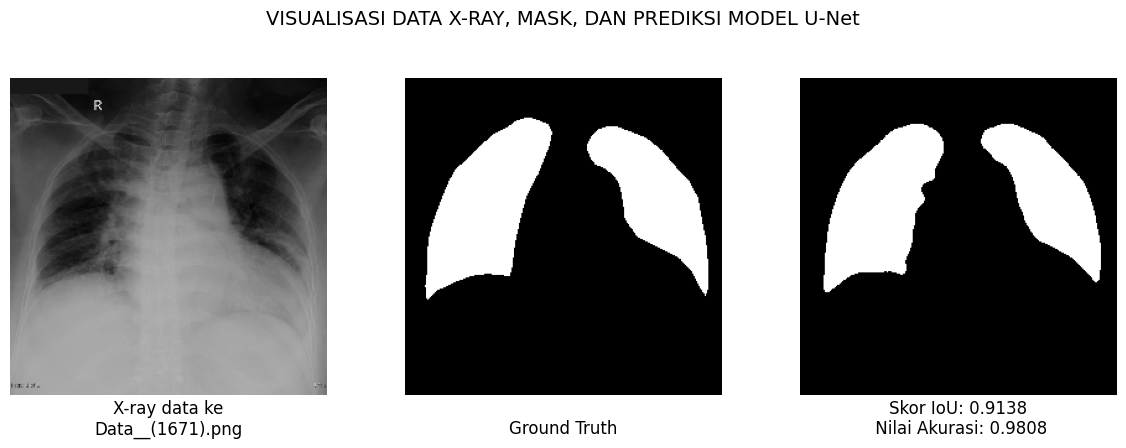

Penggunaan memori: 959.26 MB
Waktu inferensi: 6.04 detik


In [ ]:
import os # library untuk operasi sistem
import numpy as np # library untuk komputasi numerik dan manipulasi array
import matplotlib.pyplot as plt # library untuk visualisasi data
import tensorflow as tf    # library utama untuk deep learning (inisiasi model dan evaluasi model )
from tensorflow.keras.models import load_model # pustaka untuk memuat model
import psutil # library untuk memantau penggunaan sumber daya sistem (CPU, memori, dll)
import time # untuk mengukur waktu eksekusi

# --- 1. Awal waktu & memori ---
start_time = time.perf_counter() # dapatkan waktu awal
memori_awal = get_memory_usage()  # dapatkan penggunaan memori awal

# --- 2. Prediksi ---
predicted_masks = model.predict(img_array) # Gunakan model U-Net
predicted_masks = (predicted_masks > 0.5).astype(np.uint8)  # Thresholding untuk mendapatkan dara binary mask
#jika nilai prediksi > 0.5 maka dianggap sebagai 1 (putih atau postif), jika <= 0.5 dianggap sebagai 0 (negatif atau hitam)

# --- 3. Hitung IoU & Akurasi ---
binary_iou = tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5) #menghitung IoU untuk kelas positif (1) dengan threshold 0.5
accuracy = tf.keras.metrics.BinaryAccuracy() #menghitung akurasi biner

iou_scores, accuracy_scores = [], [] # menyimpan skor IoU dan akurasi untuk setiap gambar dalam bentuk list

for i in range(len(img_array)): #iterasi untuk setiap gambar
    binary_iou.update_state(mask_array[i], predicted_masks[i]) #mengupdate nialai IoU dengan ground truth dan prediksi
    iou_scores.append(binary_iou.result().numpy()) #menyimpan hasil IoU
    binary_iou.reset_state() #reset state untuk perhitungan berikutnya

    accuracy.update_state(mask_array[i], predicted_masks[i]) #mengupdate nilai akurasi dengan ground truth dan prediksi
    accuracy_scores.append(accuracy.result().numpy()) #menyimpan hasil akurasi
    accuracy.reset_state() # reset state untuk perhitungan berikutnya

print(f"Rata-rata IoU: {np.mean(iou_scores):.4f}") #menampilkan rata-rata IoU dengan 4 desimal menggunakan np.mean
print(f"Rata-rata Akurasi: {np.mean(accuracy_scores):.4f}") #menampilkan rata-rata akurasi dengan 4 desimal menggunakan np.mean

# --- 4. Visualisasi ---

for i in range(len(img_array)): #  ITERASI UNTUK SETIAP GAMBAR  SESAUAI DENGAN JUMLAH DATA
    plt.figure(figsize=(12, 4)) # set ukuran gambar
    plt.suptitle("VISUALISASI DATA X-RAY, MASK, DAN PREDIKSI MODEL U-Net", fontsize=14, y=1.05) #set judul utama

    # X-ray
    plt.subplot(1, 3, 1) # LETAKAN PADA BARIS 1 KOLOM 3 POSISI 1
    plt.imshow(img_array[i].squeeze(), cmap='gray') # tampilkan gambar X-ray
    plt.title(f"X-ray data ke\n{filenames[i]}", y=-0.15) # set judul dengan 
    plt.axis("off")    # matikan axis

    # Ground Truth
    plt.subplot(1, 3, 2) # LETAKAN PADA BARIS 1 KOLOM 3 POSISI 2
    plt.imshow(mask_array[i].squeeze(), cmap='gray') # tampilkan gambar Mask
    plt.title("Ground Truth", y=-0.15) # set judul
    plt.axis("off")

    # Prediksi
    plt.subplot(1, 3, 3) # LETAKAN PADA BARIS 1 KOLOM 3 POSISI 3
    plt.imshow(predicted_masks[i].squeeze(), cmap='gray') # tampilkan gambar Prediksi
    plt.title(f"Hasil Prediksi\nSkor IoU: {iou_scores[i]:.4f}\n Nilai Akurasi: {accuracy_scores[i]:.4f}", y=-0.15) # set judul 
    plt.axis("off")

    plt.tight_layout() # mengatur layout agar tidak tumpang tindih
    plt.show() # menampilkan gambar

# --- 5. Akhir waktu & memori ---
stop_time = time.perf_counter() # dapatkan waktu akhir
memori_akhir = get_memory_usage()  # dapatkan penggunaan memori akhir

# --- 6. Hitung selisih ---
waktuinferensi = stop_time - start_time # menghitung waktu eksekusi
totalmemori = memori_akhir - memori_awal # menghitung penggunaan memori


print(f"Penggunaan memori: {totalmemori:.2f} MB") # menampilkan penggunaan memori
print(f"Waktu inferensi: {waktuinferensi:.2f} detik") # menampilkan waktu inferensi


# <b>Model L-UNet</b>

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Rata-rata IoU: 0.9252
Rata-rata Akurasi: 0.9782


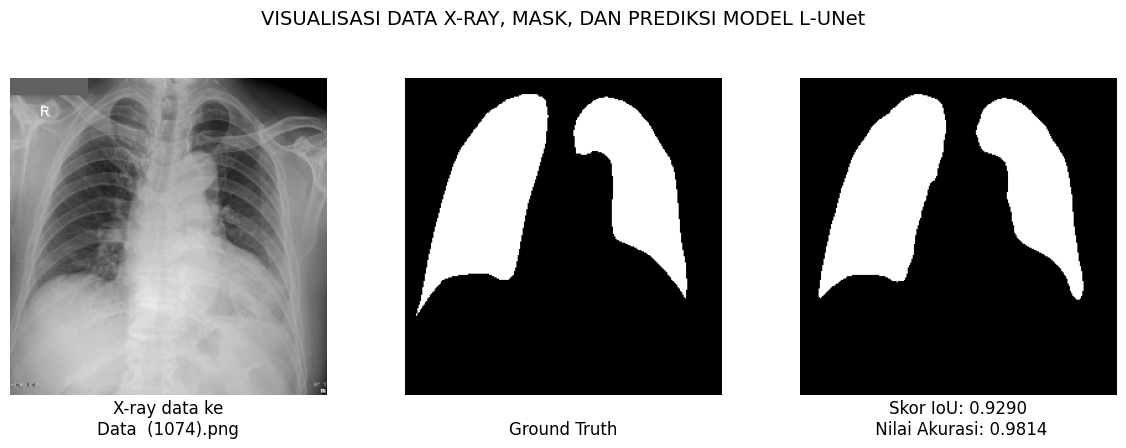

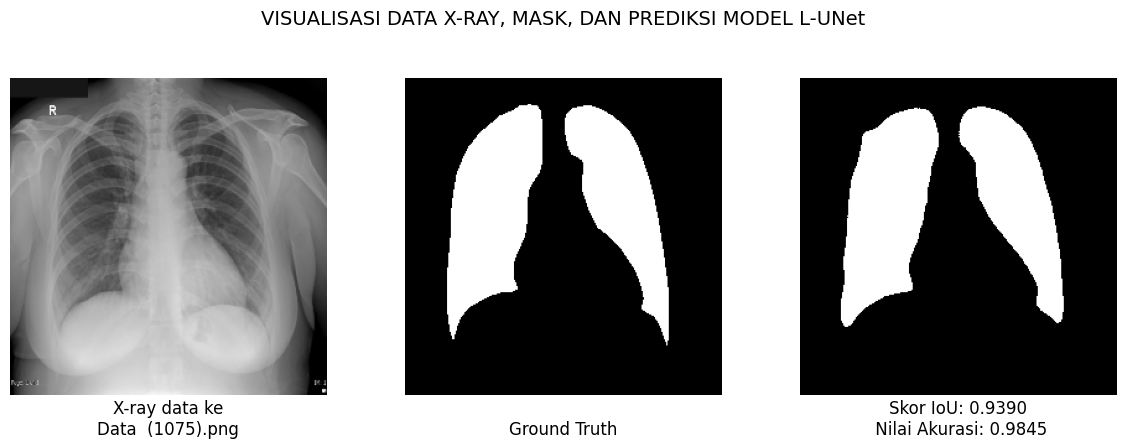

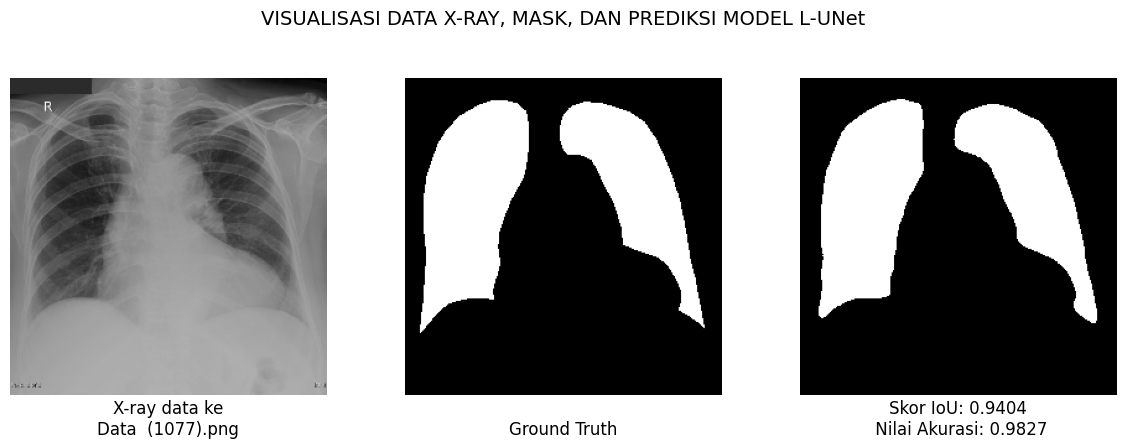

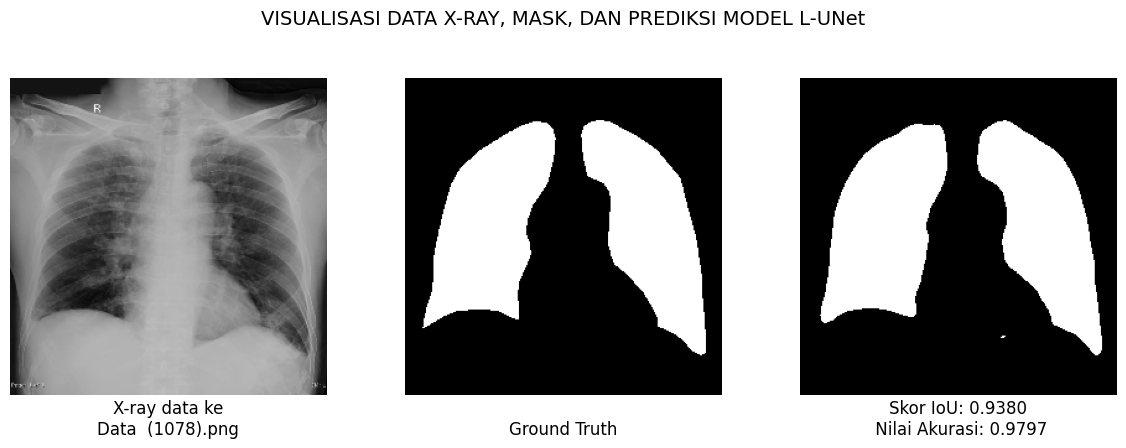

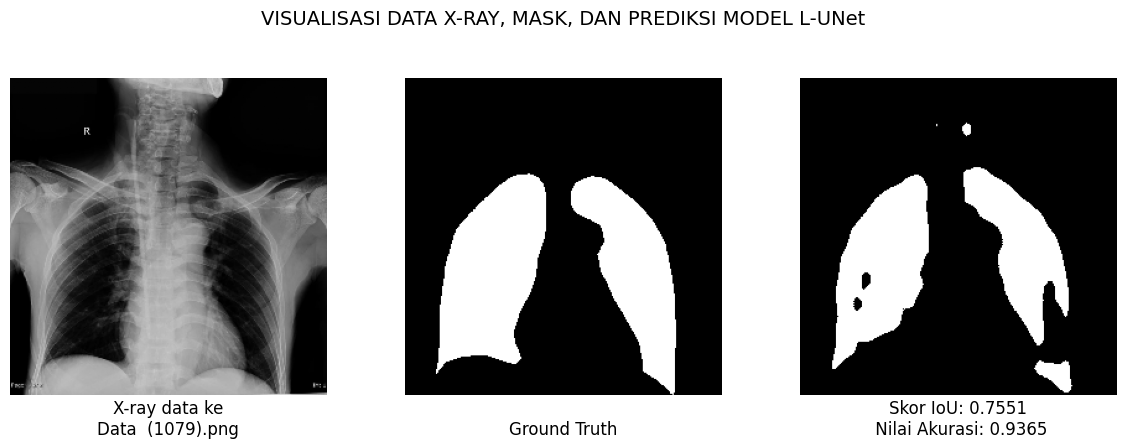

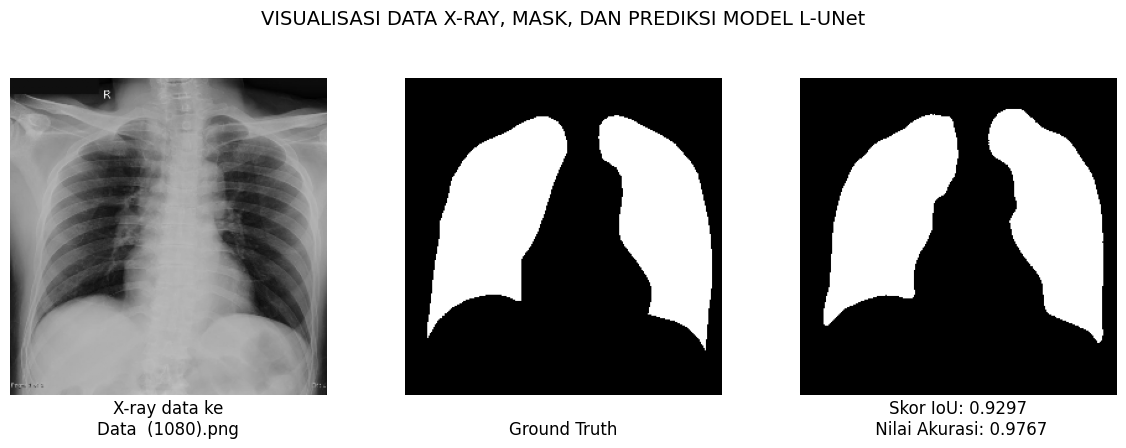

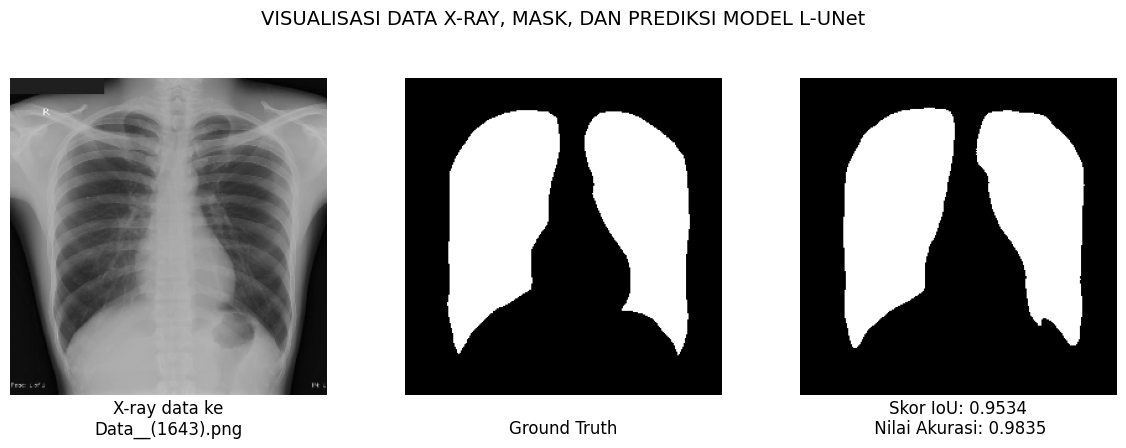

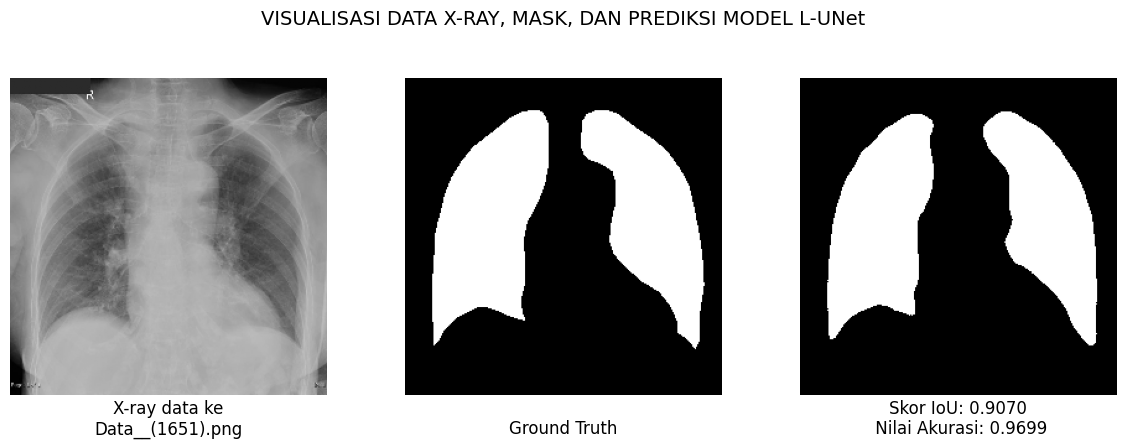

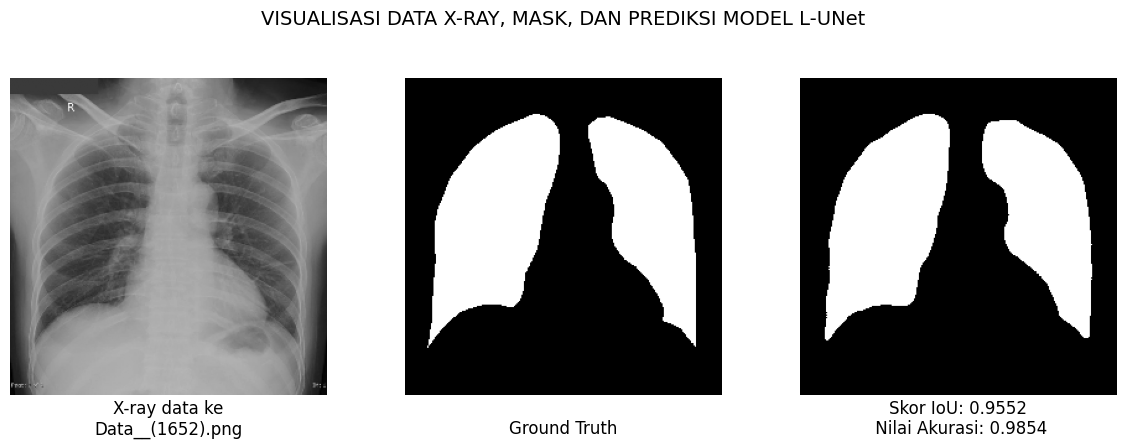

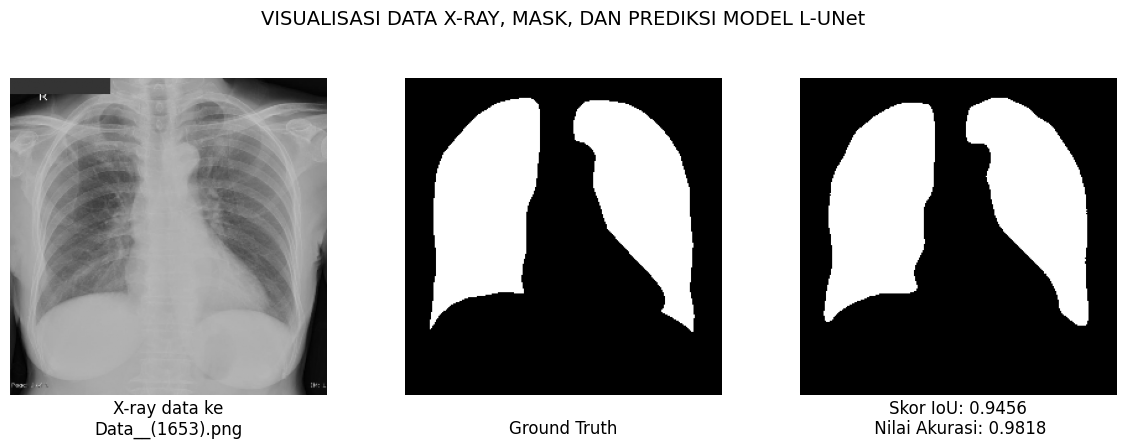

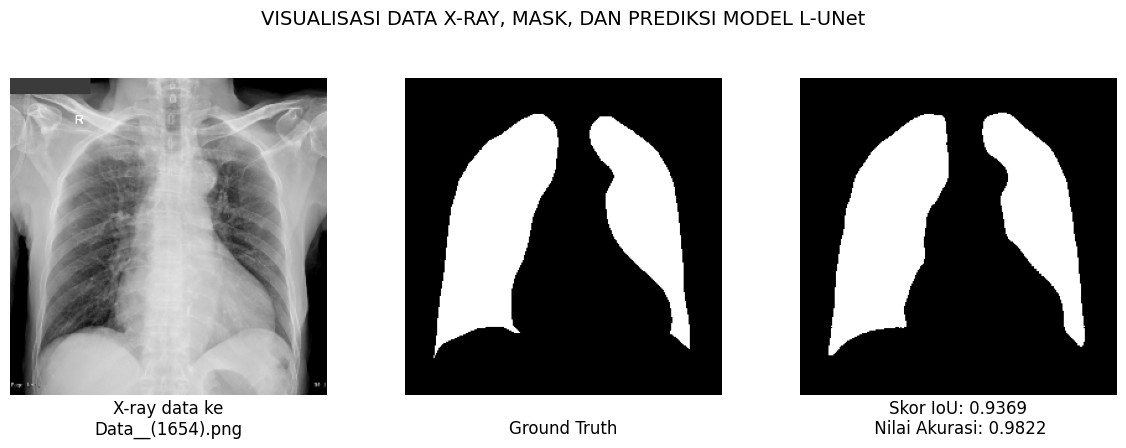

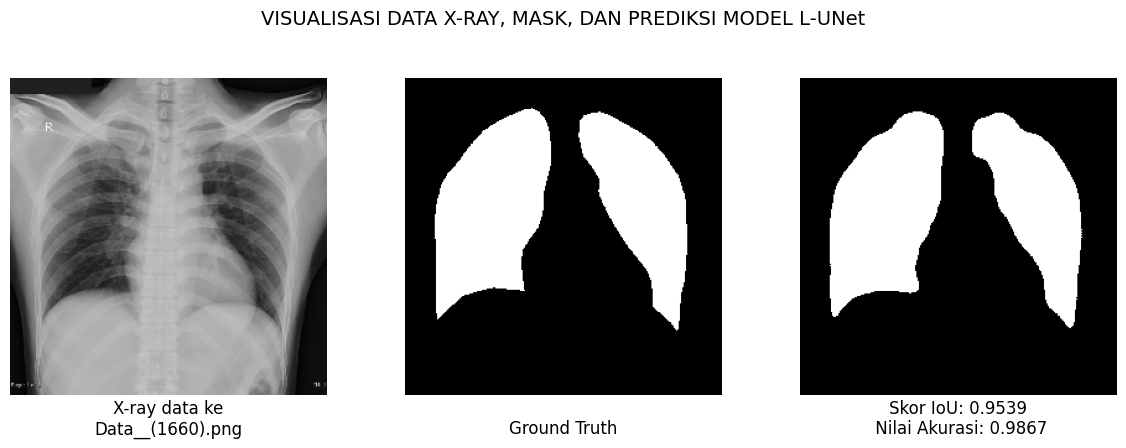

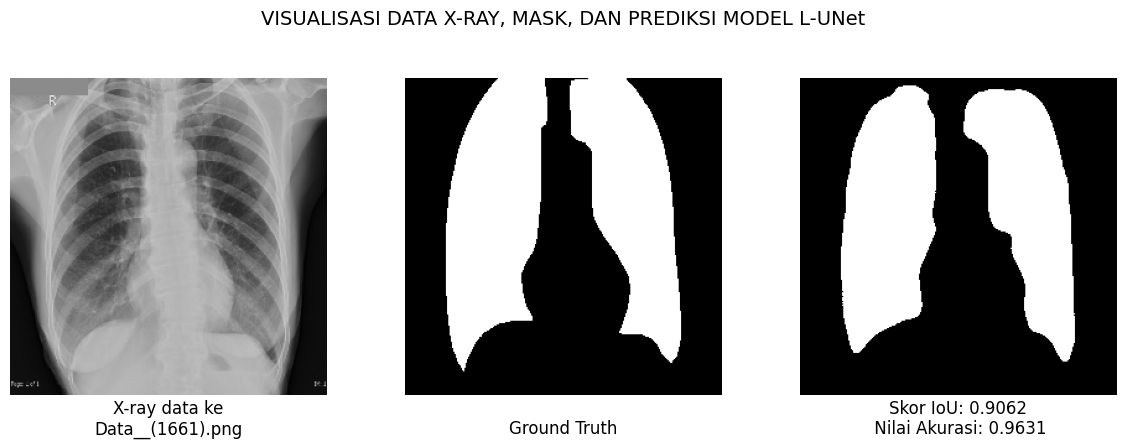

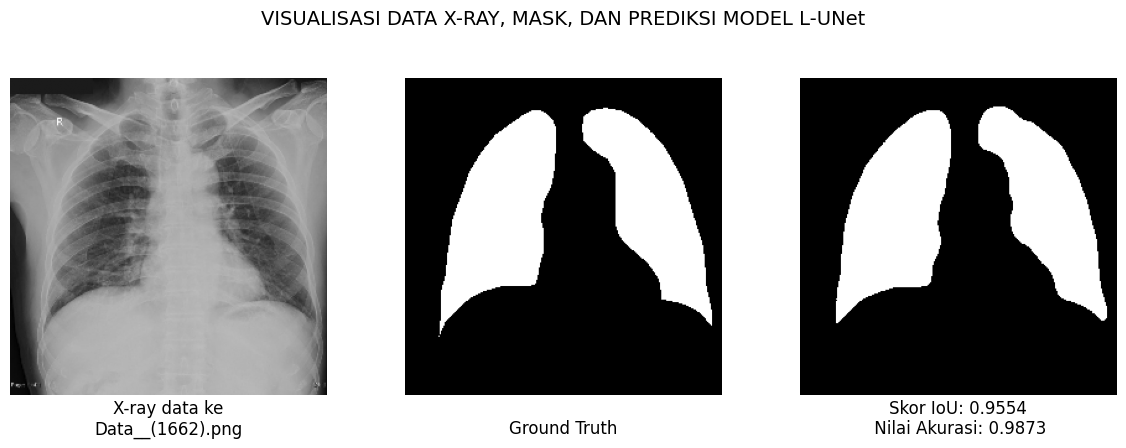

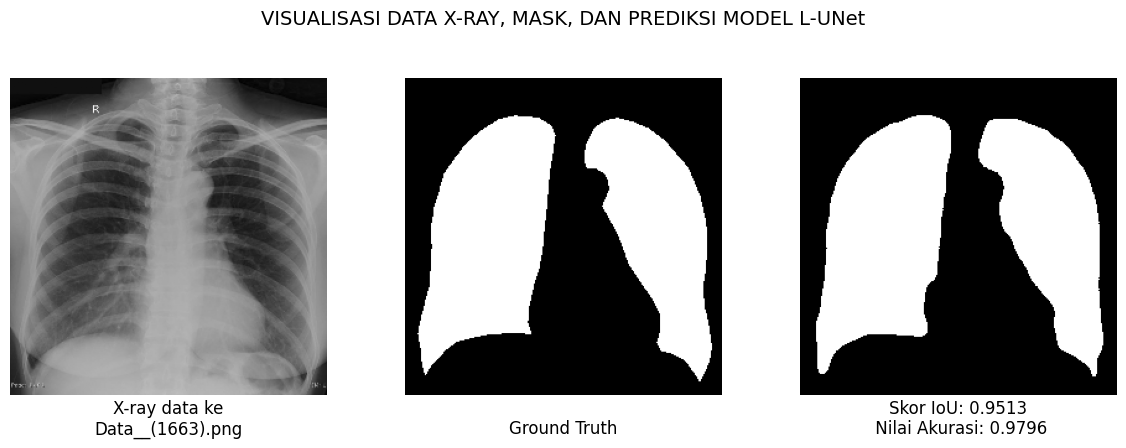

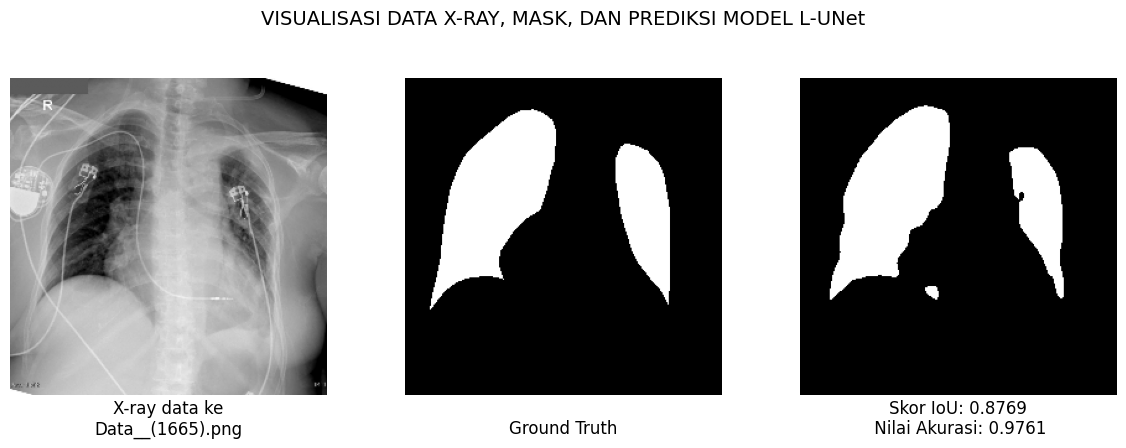

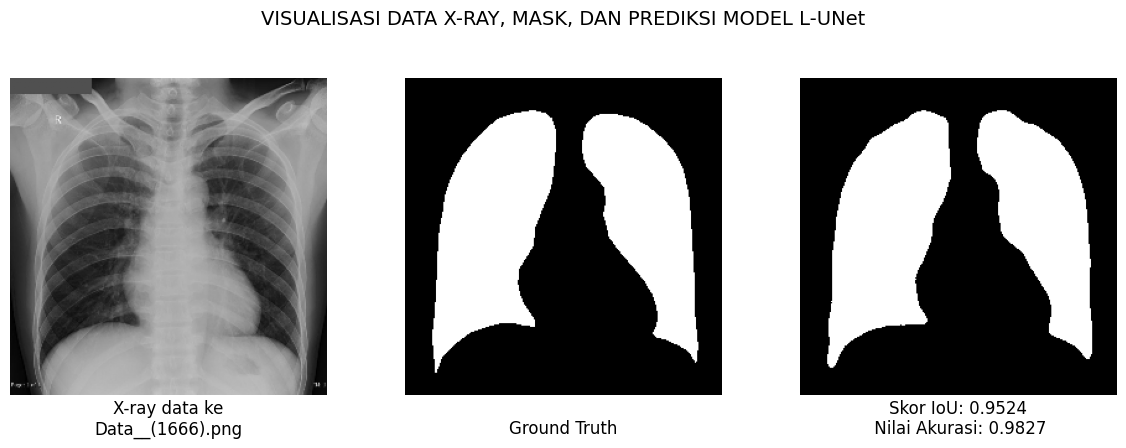

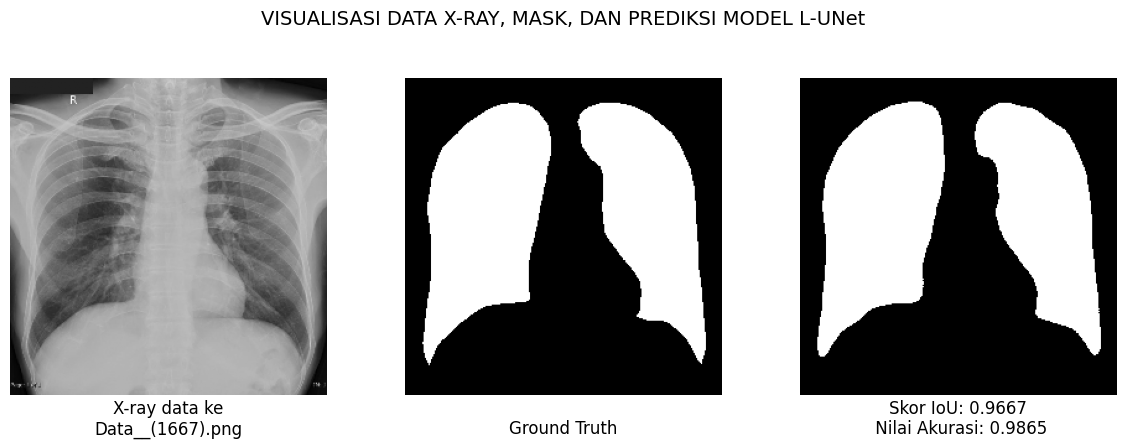

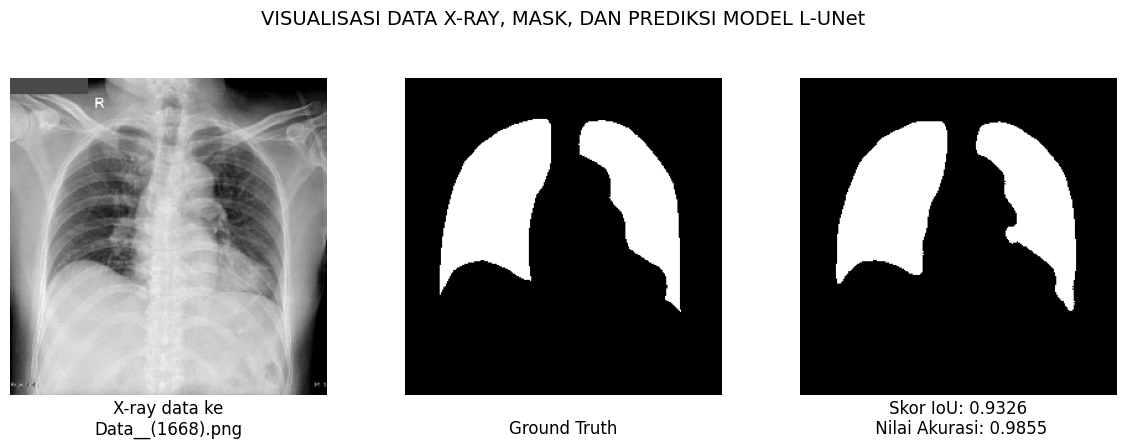

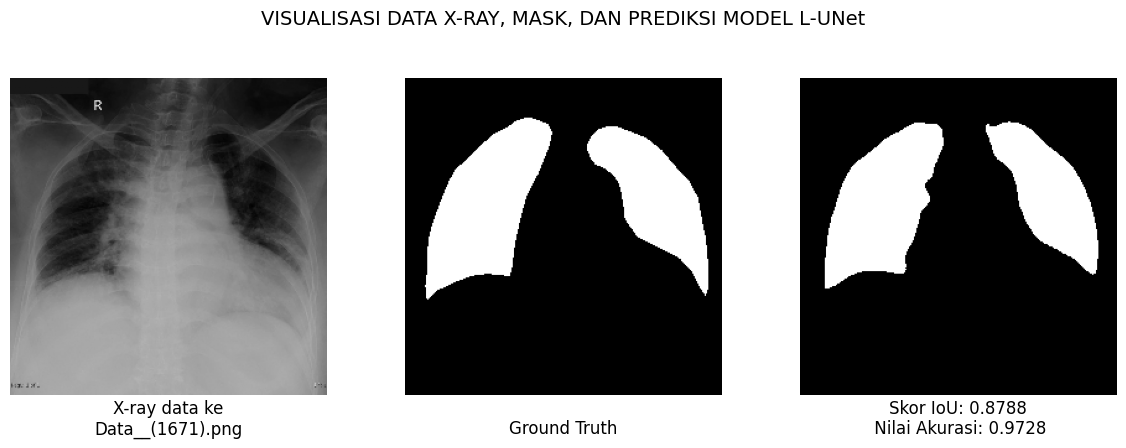

Penggunaan memori: 80.94 MB
Waktu inferensi: 5.16 detik


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
import psutil
import time

# --- 1. Awal waktu & memori ---
start_time = time.perf_counter()
memori_awal = get_memory_usage()  

# --- 2. Prediksi ---
predicted_masks = model2.predict(img_array)
predicted_masks = (predicted_masks > 0.5).astype(np.uint8)

# --- 3. Hitung IoU & Akurasi ---
binary_iou = tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)
accuracy = tf.keras.metrics.BinaryAccuracy()

iou_scores, accuracy_scores = [], []

for i in range(len(img_array)):
    binary_iou.update_state(mask_array[i], predicted_masks[i])
    iou_scores.append(binary_iou.result().numpy())
    binary_iou.reset_state()

    accuracy.update_state(mask_array[i], predicted_masks[i])
    accuracy_scores.append(accuracy.result().numpy())
    accuracy.reset_state()

print(f"Rata-rata IoU: {np.mean(iou_scores):.4f}")
print(f"Rata-rata Akurasi: {np.mean(accuracy_scores):.4f}")

# --- 4. Visualisasi ---

for i in range(len(img_array)):
    plt.figure(figsize=(12, 4))
    plt.suptitle("VISUALISASI DATA X-RAY, MASK, DAN PREDIKSI MODEL L-UNet", fontsize=14, y=1.05)

    # X-ray
    plt.subplot(1, 3, 1)
    plt.imshow(img_array[i].squeeze(), cmap='gray')
    plt.title(f"X-ray data ke\n{filenames[i]}", y=-0.15)
    plt.axis("off")

    # Ground Truth
    plt.subplot(1, 3, 2)
    plt.imshow(mask_array[i].squeeze(), cmap='gray')
    plt.title("Ground Truth", y=-0.15)
    plt.axis("off")

    # Prediksi
    plt.subplot(1, 3, 3)
    plt.imshow(predicted_masks[i].squeeze(), cmap='gray')
    plt.title(f"Hasil Prediksi\nSkor IoU: {iou_scores[i]:.4f}\n Nilai Akurasi: {accuracy_scores[i]:.4f}", y=-0.15)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- 5. Akhir waktu & memori ---
stop_time = time.perf_counter()
memori_akhir = get_memory_usage()   # <-- PAKAI ()

# --- 6. Hitung selisih ---
waktuinferensi = stop_time - start_time
totalmemori = memori_akhir - memori_awal


print(f"Penggunaan memori: {totalmemori:.2f} MB")
print(f"Waktu inferensi: {waktuinferensi:.2f} detik")

# <b> Tflite L-UNet</b>

<>:14: SyntaxWarning: invalid escape sequence '\L'
<>:14: SyntaxWarning: invalid escape sequence '\L'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13988\1787345661.py:14: SyntaxWarning: invalid escape sequence '\L'
  interpreter = tf.lite.Interpreter(model_path="Model AI\L-UNet.tflite")


Rata-rata IoU: 0.9252
Rata-rata Akurasi: 0.9782


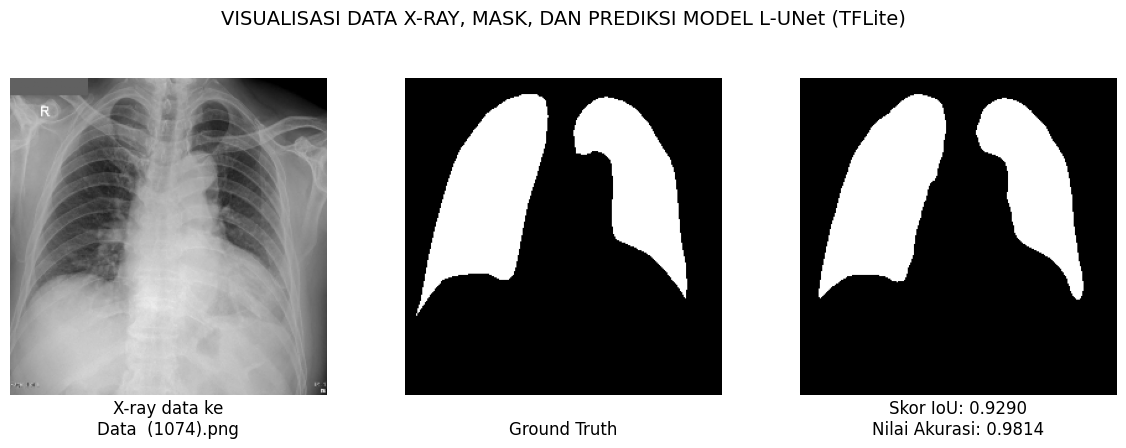

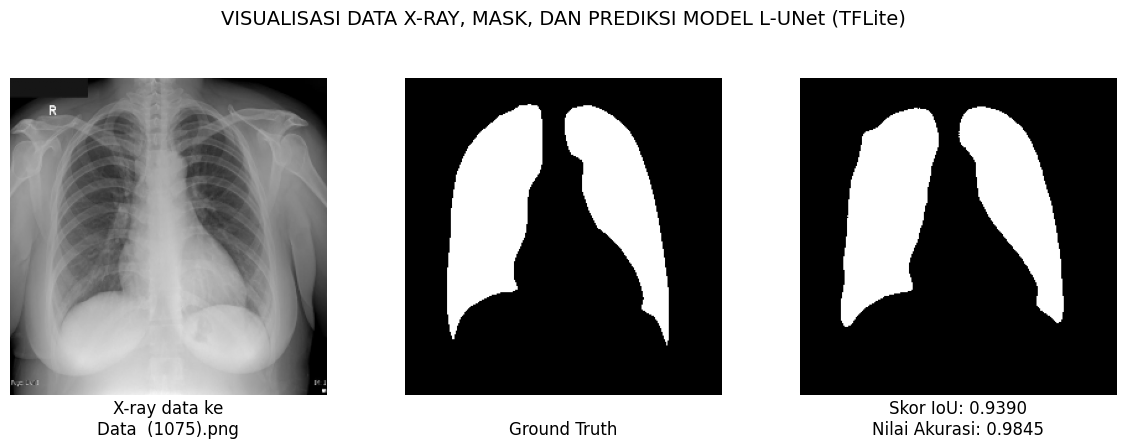

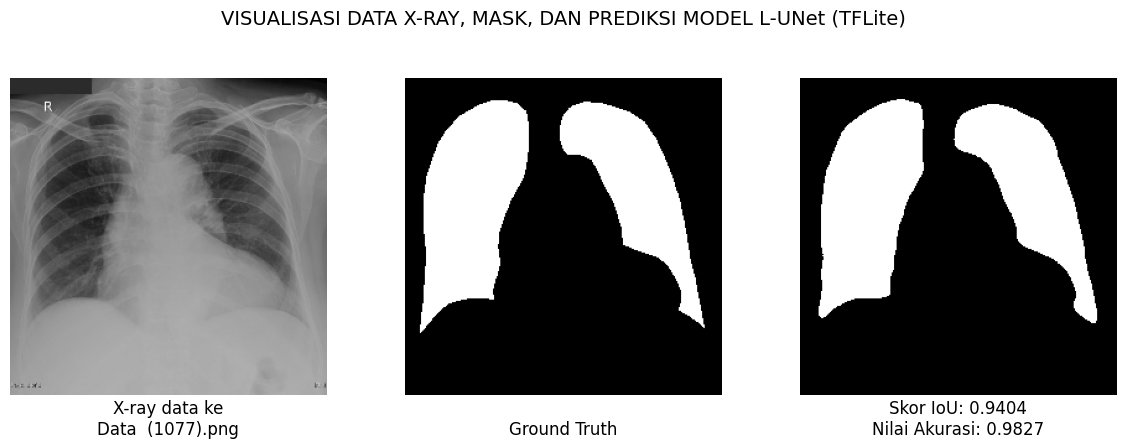

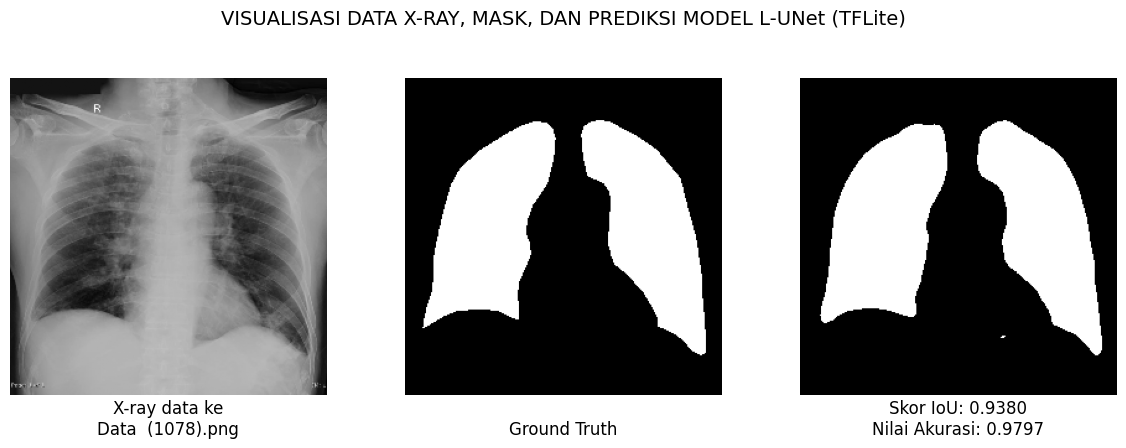

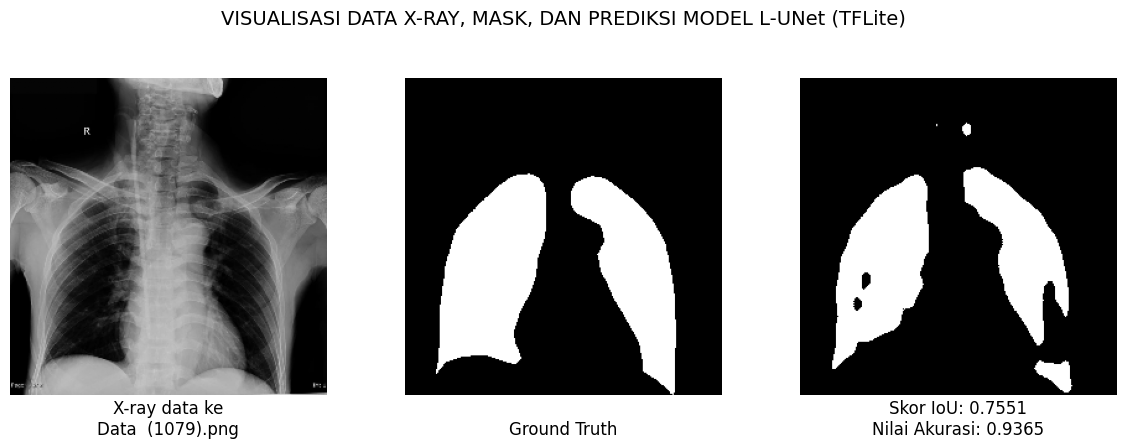

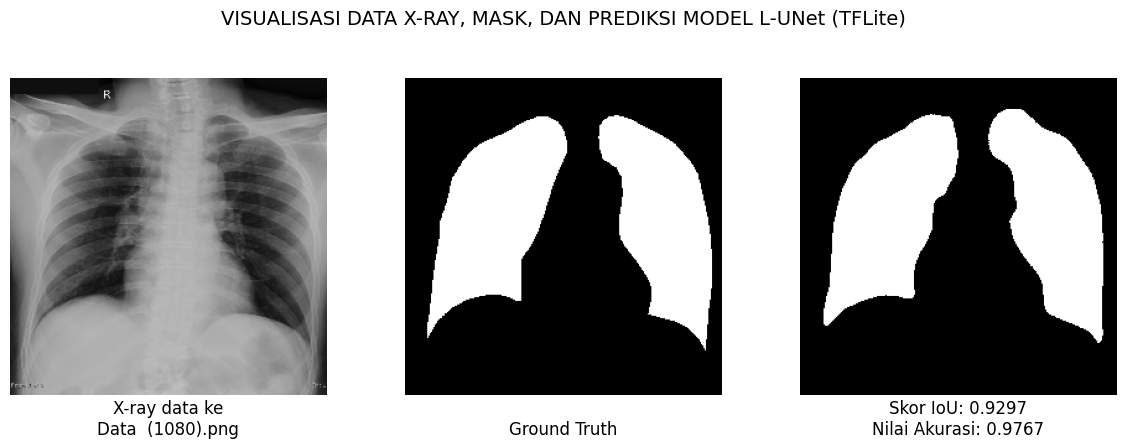

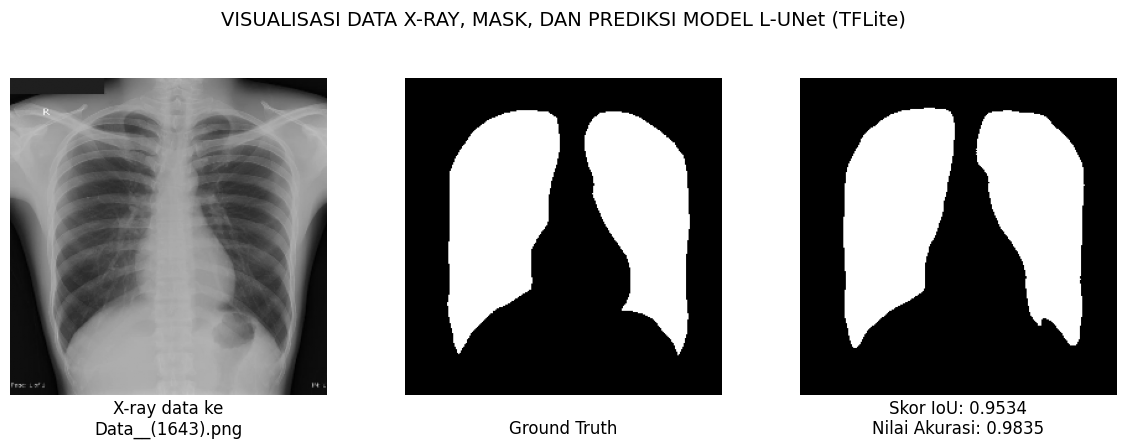

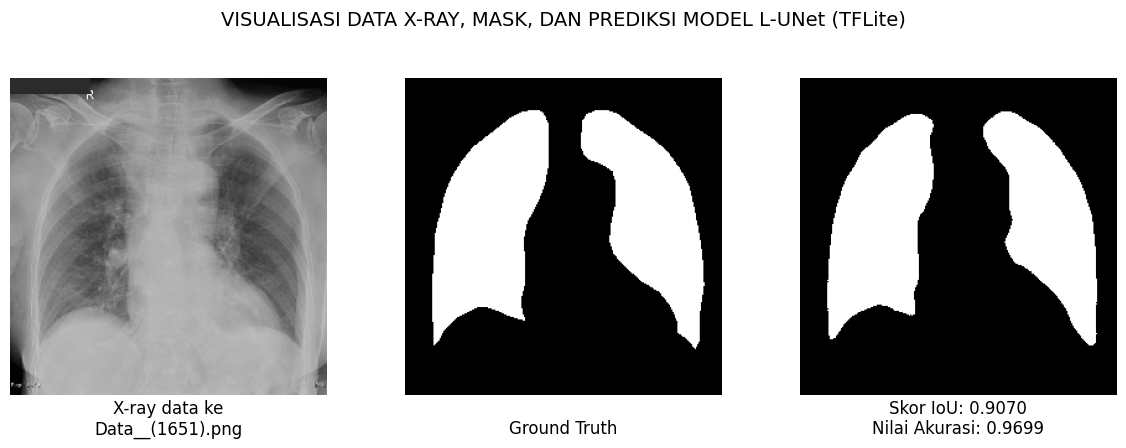

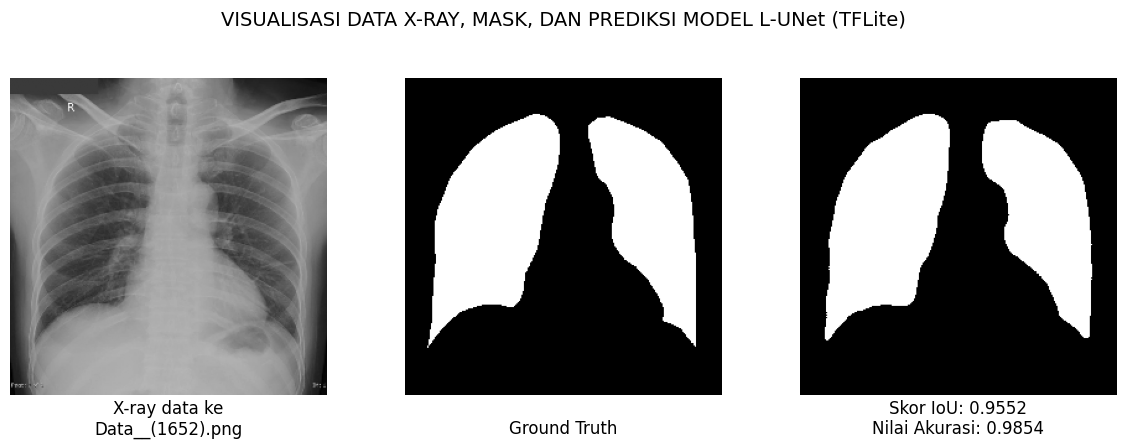

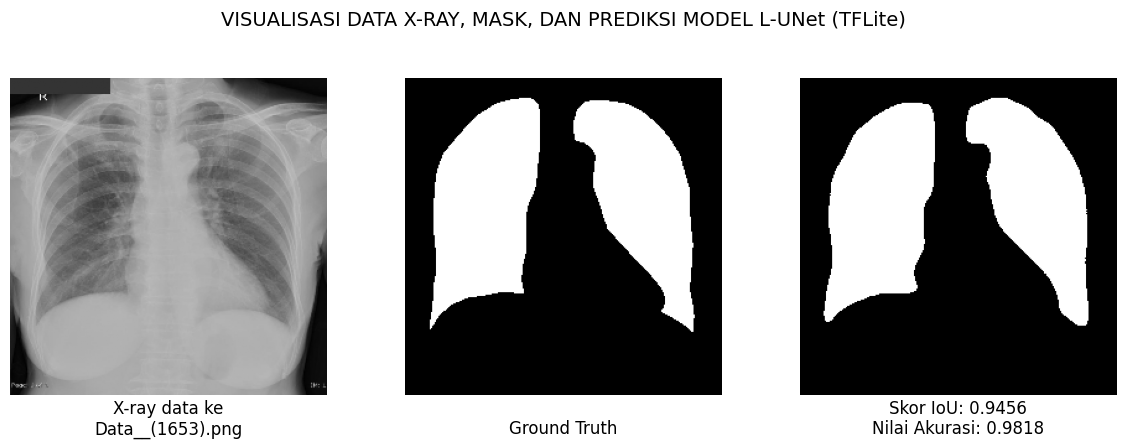

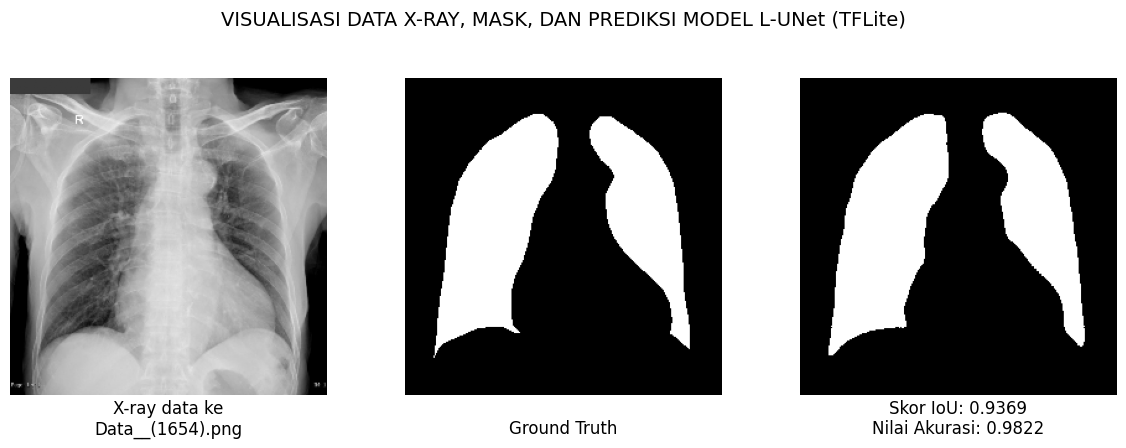

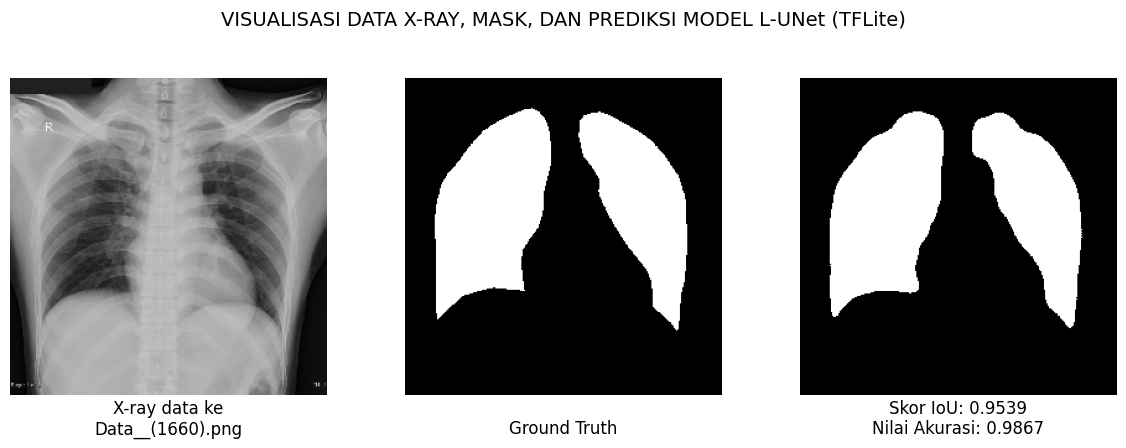

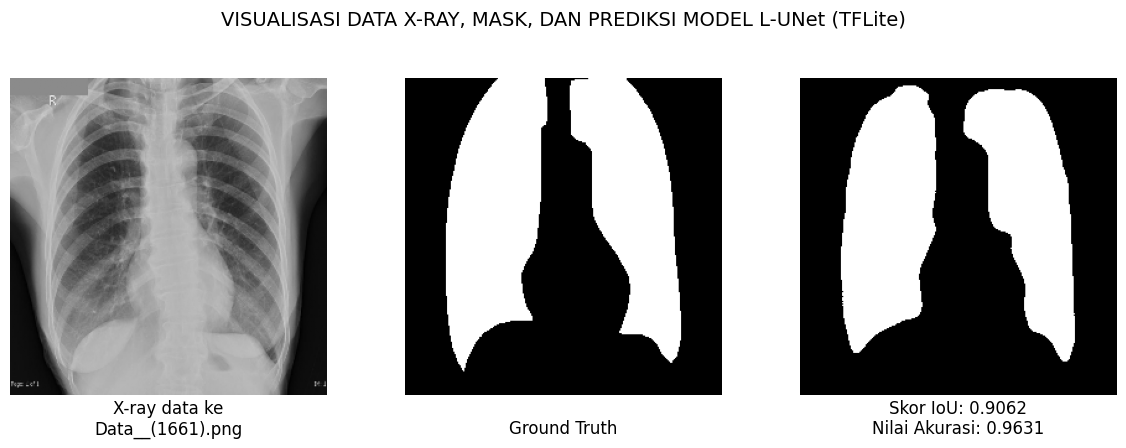

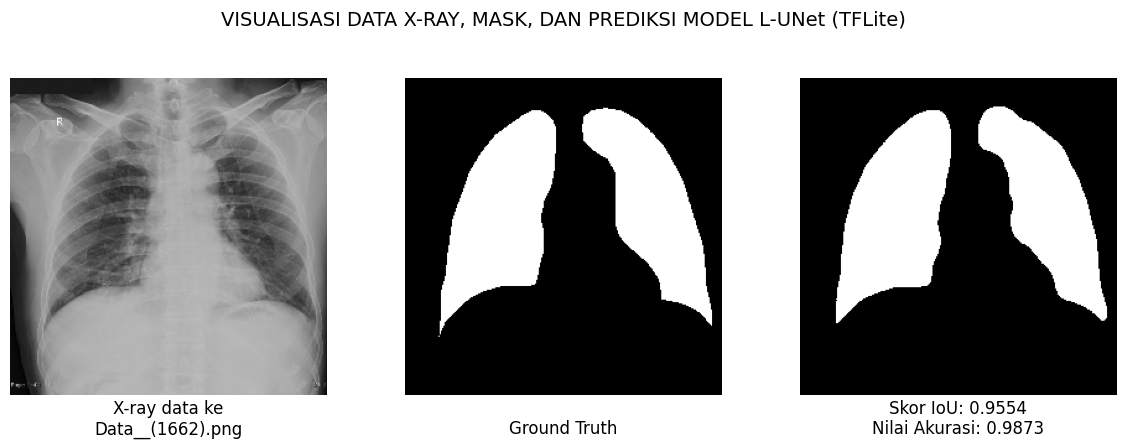

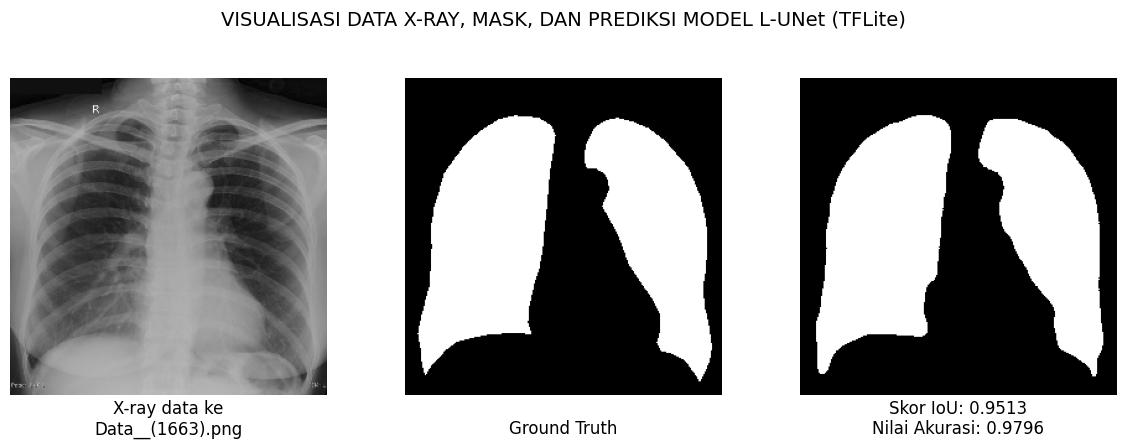

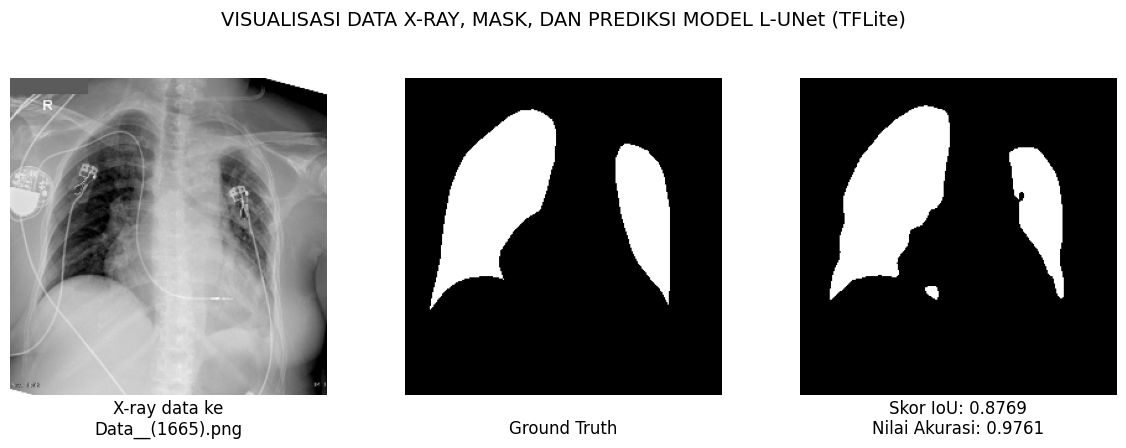

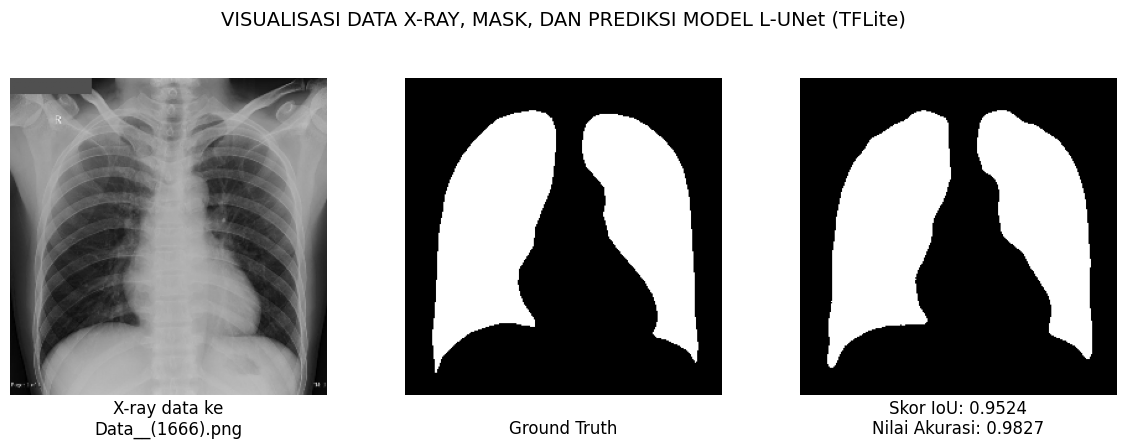

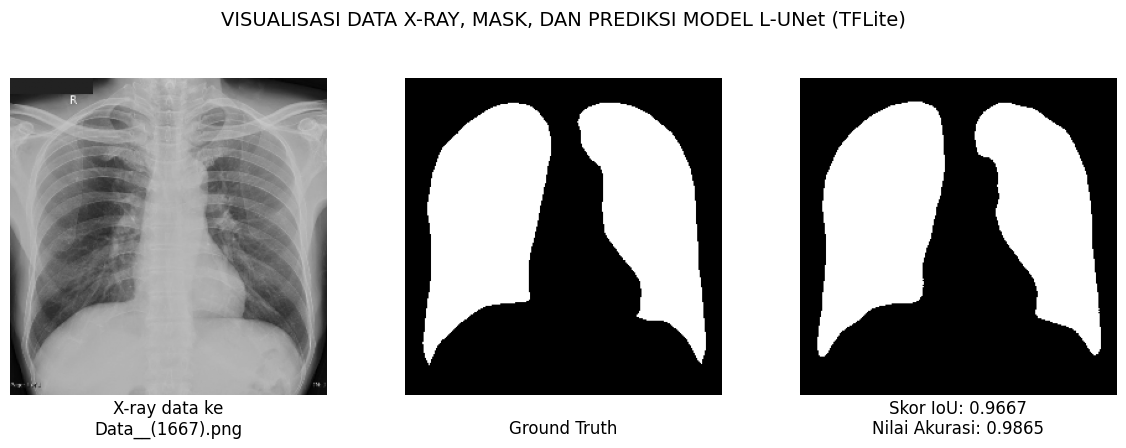

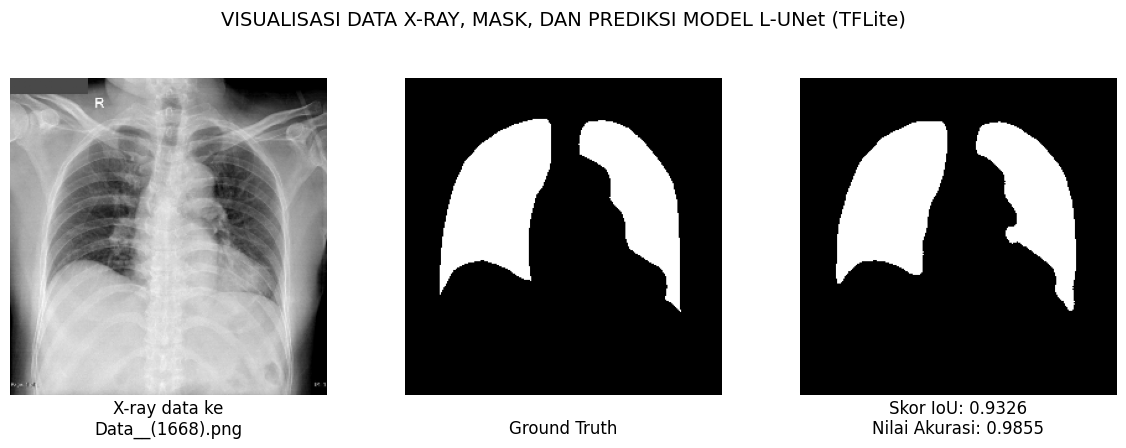

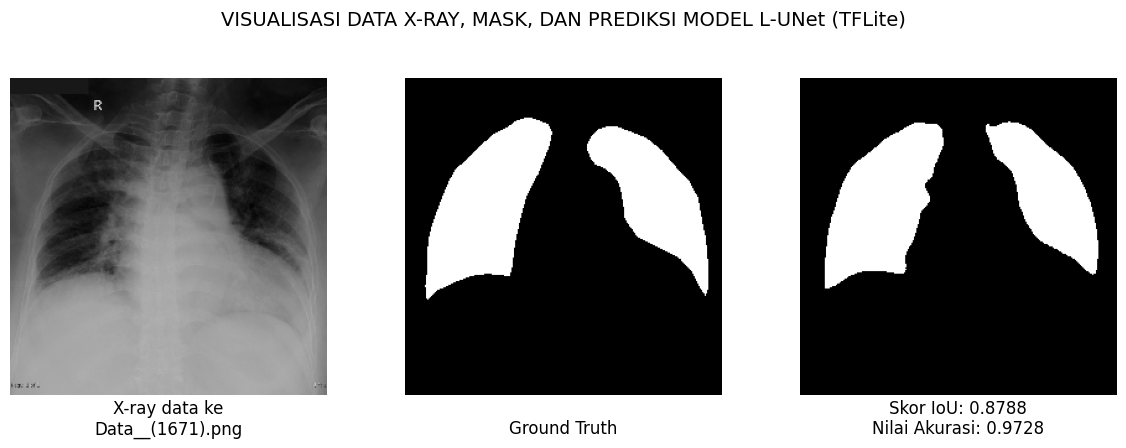

Penggunaan memori: 105.87 MB
Waktu inferensi: 8.81 detik


In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import psutil
import time

# --- Fungsi cek memori ---
process = psutil.Process(os.getpid())
def get_memory_usage():
    return process.memory_info().rss / 1024 ** 2  # MB

# --- Load model TFLite ---
interpreter = tf.lite.Interpreter(model_path="Model AI\L-UNet.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# --- 1. Awal waktu & memori ---
start_time = time.perf_counter()
memori_awal = get_memory_usage()

# --- 2. Prediksi dengan TFLite ---
predicted_masks = []
for img in img_array:
    # Tambahkan batch dimension (1, 256, 256, 1)
    input_data = np.expand_dims(img, axis=0)

    # Set input ke model
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()

    # Ambil output
    output_data = interpreter.get_tensor(output_details[0]['index'])
    output_mask = (output_data > 0.5).astype(np.uint8).squeeze()

    predicted_masks.append(output_mask)

predicted_masks = np.array(predicted_masks)

# --- 3. Hitung IoU & Akurasi ---
binary_iou = tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)
accuracy = tf.keras.metrics.BinaryAccuracy()

iou_scores, accuracy_scores = [], []

for i in range(len(img_array)):
    binary_iou.update_state(mask_array[i], predicted_masks[i])
    iou_scores.append(binary_iou.result().numpy())
    binary_iou.reset_state()

    accuracy.update_state(mask_array[i], predicted_masks[i])
    accuracy_scores.append(accuracy.result().numpy())
    accuracy.reset_state()

print(f"Rata-rata IoU: {np.mean(iou_scores):.4f}")
print(f"Rata-rata Akurasi: {np.mean(accuracy_scores):.4f}")

# --- 4. Visualisasi ---
for i in range(len(img_array)):
    plt.figure(figsize=(12, 4))
    plt.suptitle("VISUALISASI DATA X-RAY, MASK, DAN PREDIKSI MODEL L-UNet (TFLite)", fontsize=14, y=1.05)

    # X-ray
    plt.subplot(1, 3, 1)
    plt.imshow(img_array[i].squeeze(), cmap='gray')
    plt.title(f"X-ray data ke\n{filenames[i]}", y=-0.15)
    plt.axis("off")

    # Ground Truth
    plt.subplot(1, 3, 2)
    plt.imshow(mask_array[i].squeeze(), cmap='gray')
    plt.title("Ground Truth", y=-0.15)
    plt.axis("off")

    # Prediksi
    plt.subplot(1, 3, 3)
    plt.imshow(predicted_masks[i].squeeze(), cmap='gray')
    plt.title(f"Hasil Prediksi\nSkor IoU: {iou_scores[i]:.4f}\nNilai Akurasi: {accuracy_scores[i]:.4f}", y=-0.15)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- 5. Akhir waktu & memori ---
stop_time = time.perf_counter()
memori_akhir = get_memory_usage()

# --- 6. Hitung selisih ---
waktuinferensi = stop_time - start_time
totalmemori = memori_akhir - memori_awal

print(f"Penggunaan memori: {totalmemori:.2f} MB")
print(f"Waktu inferensi: {waktuinferensi:.2f} detik")
